In [1]:
# Renko Chart Analysis Mean Reversion Strategy

#This notebook builds a Renko chart from historical OHLC data, calculates technical indicators, and generates buy/sell signals based on renko bricks .
    

Summary of Mean Reversion Strategy
Strategy Overview
Component	Description
Entry Type	Mean Reversion (fade extremes)
Long Entry	Z-Score < -1.65 AND Price < Inner Lower BB AND Price crosses above MA Fast
Short Entry	Z-Score > +1.65 AND Price > Inner Upper BB AND Price crosses below MA Fast
Scale Out	50% position when price crosses MA Fast in opposite direction
Full Exit	Remaining 50% when Stochastic crosses in overbought/oversold zone
Stop Loss	2 bricks from entry
Indicators Used
Indicator	Parameters	Purpose
Bollinger Bands (Outer)	20 period, 2 std dev	Extreme boundaries
Bollinger Bands (Inner)	20 period, 1.5 std dev	Entry trigger zone
Z-Score	20 period, ±1.65 threshold	Oversold/Overbought detection
MA Mean Target	20 period	Mean reversion target
MA Fast	3 period	Entry/Exit timing
Stochastic	K=10, D=7, Smoothing=3	Exit confirmation
Chart Legend
Symbol	Meaning
▲ (Lime)	Long Entry
▼ (Magenta)	Short Entry
■ (Cyan)	Scale Out (50%)
✕ (Yellow)	Full Exit
Orange Lines	Inner Bollinger Bands
Red Dashed Lines	Outer Bollinger Bands
Blue Line	MA 20 (Mean Target)
Purple Line	MA Fast (3)
Red Dotted Line	Stop Loss Level

In [2]:
## 1. Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
# Ticker and date range
ticker = 'CL=F'  # Crude Oil Futures
start_date = '2026-02-12'
end_date = '2026-03-09'

# Renko brick size - IMPORTANT: Should be appropriate for the asset
# For crude oil (~$70), recommended brick size: $0.25 - $1.00
brick_size = 0.10  

# ========== TRANSACTION COSTS ==========
COMMISSION_PER_TRADE = 2.50      # Commission per side (entry or exit) in dollars
SLIPPAGE_PER_TRADE = 0.02        # Slippage in price units (e.g., $0.02 per barrel)
INCLUDE_TRANSACTION_COSTS = True  # Toggle transaction costs on/off

# ========== CONTRACT SPECIFICATIONS ==========
# Crude Oil Futures (CL): 1,000 barrels per contract
# Mini Crude Oil (QM): 500 barrels per contract
# Micro Crude Oil (MCL): 100 barrels per contract
CONTRACT_SIZE = 100  # Using Micro contracts for smaller accounts
MIN_CONTRACTS = 1    # Minimum number of contracts per trade

# ========== MEAN REVERSION STRATEGY PARAMETERS ==========

# Bollinger Bands Parameters
BOLLINGER_BAND_PERIOD_OUTER = 20
BOLLINGER_BAND_STD_DEV_OUTER = 2.0
BOLLINGER_BAND_PERIOD_INNER = 20
BOLLINGER_BAND_STD_DEV_INNER = 1.5

# Z-Score Parameters
Z_SCORE_PERIOD = 20
Z_SCORE_EXTREME_THRESHOLD = 1.65

# Moving Average Parameters
MA_MEAN_TARGET_PERIOD = 20
MA_FAST_ENTRY_EXIT_PERIOD = 3
MA_FAST_ENTRY_EXIT_OFFSET = 1

# Stochastic Parameters
STOCHASTIC_K_PERIOD = 10
STOCHASTIC_D_PERIOD = 7
STOCHASTIC_SMOOTHING_PERIOD = 3
STOCHASTIC_EXIT_LEVEL_LONG = 20
STOCHASTIC_EXIT_LEVEL_SHORT = 80

# Stop Loss (in number of bricks)
STOP_LOSS_BRICKS = 2

# Entry Lookback
ENTRY_LOOKBACK = 2

# ========== VALIDATION WARNINGS ==========
print("=" * 70)
print("                    CONFIGURATION VALIDATION")
print("=" * 70)

# Download a sample to get current price
import yfinance as yf
sample_data = yf.download(ticker, period='5d', progress=False)
if len(sample_data) > 0:
    current_price = sample_data['Close'].iloc[-1]
    if hasattr(current_price, 'item'):
        current_price = current_price.item()
    
    brick_pct = (brick_size / current_price) * 100
    
    print(f"Ticker:              {ticker}")
    print(f"Current Price:       ${current_price:.2f}")
    print(f"Brick Size:          ${brick_size:.2f} ({brick_pct:.2f}% of price)")
    print(f"Stop Loss:           {STOP_LOSS_BRICKS} bricks (${STOP_LOSS_BRICKS * brick_size:.2f})")
    print(f"Contract Size:       {CONTRACT_SIZE} units")
    print(f"Commission/Trade:    ${COMMISSION_PER_TRADE:.2f}")
    print(f"Slippage/Trade:      ${SLIPPAGE_PER_TRADE:.2f}")
    
    # Warnings
    if brick_pct < 0.3:
        print(f"\n⚠️  WARNING: Brick size ({brick_pct:.2f}%) is very small!")
        print(f"    This will generate excessive trades and unrealistic results.")
        print(f"    Recommended: At least 0.5% of price (${current_price * 0.005:.2f})")
    
    if brick_pct > 3:
        print(f"\n⚠️  WARNING: Brick size ({brick_pct:.2f}%) is very large!")
        print(f"    This may generate too few trades for meaningful analysis.")
    
    # Estimate daily bricks
    if len(sample_data) > 1:
        daily_range = (sample_data['High'] - sample_data['Low']).mean()
        if hasattr(daily_range, 'item'):
            daily_range = daily_range.item()
        estimated_daily_bricks = daily_range / brick_size
        print(f"\nEstimated Bricks/Day: ~{estimated_daily_bricks:.1f}")
        
        if estimated_daily_bricks > 20:
            print(f"⚠️  WARNING: Too many bricks per day - likely over-trading!")
else:
    print(f"Could not fetch data for {ticker}")

print("=" * 70)

                    CONFIGURATION VALIDATION


/var/folders/2v/mkg1tcnj0dsgbn4wspnx8l0h0000gn/T/ipykernel_5626/2650463043.py:59: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sample_data = yf.download(ticker, period='5d', progress=False)


Ticker:              CL=F
Current Price:       $89.03
Brick Size:          $0.10 (0.11% of price)
Stop Loss:           2 bricks ($0.20)
Contract Size:       100 units
Commission/Trade:    $2.50
Slippage/Trade:      $0.02

⚠️  WARNING: Brick size (0.11%) is very small!
    This will generate excessive trades and unrealistic results.
    Recommended: At least 0.5% of price ($0.45)

Estimated Bricks/Day: ~167.3
⚠️  WARNING: Too many bricks per day - likely over-trading!


In [4]:
# Cell 7 - Download Intraday Data
# Use 1-hour or 15-minute data for realistic backtesting

# For recent data (last 60 days) - use interval='1h'
# df = yf.download(ticker, start=start_date, end=end_date, interval='1h')

# OR for 15-minute data (last 60 days only)
df = yf.download(ticker, start=start_date, end=end_date, interval='15m')

# Flatten MultiIndex columns (fix for newer yfinance versions)
df.columns = df.columns.get_level_values(0)

# Keep only the essential columns
df = df[['Open', 'High', 'Low', 'Close']]

# Reset index to get Date as a column
df = df.reset_index()

# Display first few rows
df.head()

/var/folders/2v/mkg1tcnj0dsgbn4wspnx8l0h0000gn/T/ipykernel_5626/511537343.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, interval='15m')
[*********************100%***********************]  1 of 1 completed


Price,Datetime,Open,High,Low,Close
0,2026-02-12 05:00:00+00:00,64.980003,64.989998,64.769997,64.849998
1,2026-02-12 05:15:00+00:00,64.849998,64.879997,64.779999,64.800003
2,2026-02-12 05:30:00+00:00,64.790001,64.820000,64.699997,64.779999
3,2026-02-12 05:45:00+00:00,64.790001,64.910004,64.779999,64.910004
4,2026-02-12 06:00:00+00:00,64.919998,64.930000,64.820000,64.839996


In [5]:
# Cell 7 - Robust Data Download
# Download OHLC data from Yahoo Finance
df = yf.download(ticker, start=start_date, end=end_date)

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure Date is a column (not index)
if df.index.name in ['Date', 'Datetime', None]:
    df = df.reset_index()
    # Find the date column (could be 'Date', 'Datetime', 'index', or first column)
    date_col_candidates = ['Date', 'Datetime', 'index']
    date_col = None
    for col in date_col_candidates:
        if col in df.columns:
            date_col = col
            break
    
    if date_col is None:
        # Assume first column is date
        date_col = df.columns[0]
    
    # Rename to 'Date' for consistency
    if date_col != 'Date':
        df = df.rename(columns={date_col: 'Date'})

# Convert Date to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Keep only essential columns
df = df[['Date', 'Open', 'High', 'Low', 'Close']]

# Display info
print(f"Data downloaded successfully!")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total rows: {len(df)}")
df.head()

/var/folders/2v/mkg1tcnj0dsgbn4wspnx8l0h0000gn/T/ipykernel_5626/4029502584.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
Columns: ['Date', 'Open', 'High', 'Low', 'Close']
Date range: 2026-02-12 00:00:00 to 2026-03-06 00:00:00
Total rows: 16


Price,Date,Open,High,Low,Close
0,2026-02-12,64.870003,65.099998,62.389999,62.840000
1,2026-02-13,62.990002,63.259998,62.139999,62.889999
2,2026-02-17,63.299999,64.139999,61.869999,62.330002
3,2026-02-18,62.299999,65.559998,62.119999,65.190002
4,2026-02-19,65.099998,66.900002,64.879997,66.430000


In [6]:
# Convert Close prices and dates to lists
prices = df['Close'].values.flatten().tolist()

# Handle Date column - check if it exists, otherwise use index
if 'Date' in df.columns:
    dates = df['Date'].tolist()
elif 'Datetime' in df.columns:
    dates = df['Datetime'].tolist()
else:
    # Date is the index
    dates = df.index.tolist()

renko_data = []      # Stores price levels of each brick
directions = []      # 1 = up, -1 = down, 0 = neutral (first brick)
renko_dates = []     # Stores the date when each brick was formed

last_price = prices[0]
renko_data.append(last_price)
directions.append(0)
renko_dates.append(dates[0])

for idx, price in enumerate(prices):
    diff = price - last_price
    brick_moves = int(diff / brick_size)

    while brick_moves != 0:
        if brick_moves > 0:
            last_price += brick_size
            renko_data.append(last_price)
            directions.append(1)
            renko_dates.append(dates[idx])
            brick_moves -= 1
        elif brick_moves < 0:
            last_price -= brick_size
            renko_data.append(last_price)
            directions.append(-1)
            renko_dates.append(dates[idx])
            brick_moves += 1

print(f"Total Renko bricks: {len(renko_data)}")
print(f"Date range: {renko_dates[0]} to {renko_dates[-1]}")

Total Renko bricks: 313
Date range: 2026-02-12 00:00:00 to 2026-03-06 00:00:00


In [7]:
# ========== BUILD RENKO BRICKS ==========
prices = df['Close'].values.flatten().tolist()

if 'Date' in df.columns:
    dates = df['Date'].tolist()
else:
    dates = df.index.tolist()

renko_data = []
directions = []
renko_dates = []

last_price = prices[0]
renko_data.append(last_price)
directions.append(0)
renko_dates.append(dates[0])

for idx, price in enumerate(prices):
    diff = price - last_price
    brick_moves = int(diff / brick_size)

    while brick_moves != 0:
        if brick_moves > 0:
            last_price += brick_size
            renko_data.append(last_price)
            directions.append(1)
            renko_dates.append(dates[idx])
            brick_moves -= 1
        elif brick_moves < 0:
            last_price -= brick_size
            renko_data.append(last_price)
            directions.append(-1)
            renko_dates.append(dates[idx])
            brick_moves += 1

print(f"Total Renko bricks: {len(renko_data)}")

# ========== CALCULATE X AND Y POSITIONS ==========
x_positions = [0]
y_positions = [renko_data[0]]

for i in range(1, len(renko_data)):
    x_positions.append(x_positions[-1] + 1)
    if renko_data[i] > renko_data[i-1]:
        y_positions.append(y_positions[-1] + brick_size)
    else:
        y_positions.append(y_positions[-1] - brick_size)

# ========== CREATE DATAFRAME WITH INDICATORS ==========
renko_df = pd.DataFrame({
    'X': x_positions,
    'Y': y_positions,
    'Price': renko_data,
    'Direction': directions,
    'Date': renko_dates
})

renko_df['Date'] = pd.to_datetime(renko_df['Date'])

# Bollinger Bands (Outer)
renko_df['BB_Middle_Outer'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_OUTER).mean()
renko_df['BB_StdDev_Outer'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_OUTER).std()
renko_df['BB_Upper_Outer'] = renko_df['BB_Middle_Outer'] + (BOLLINGER_BAND_STD_DEV_OUTER * renko_df['BB_StdDev_Outer'])
renko_df['BB_Lower_Outer'] = renko_df['BB_Middle_Outer'] - (BOLLINGER_BAND_STD_DEV_OUTER * renko_df['BB_StdDev_Outer'])

# Bollinger Bands (Inner)
renko_df['BB_Middle_Inner'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_INNER).mean()
renko_df['BB_StdDev_Inner'] = renko_df['Price'].rolling(window=BOLLINGER_BAND_PERIOD_INNER).std()
renko_df['BB_Upper_Inner'] = renko_df['BB_Middle_Inner'] + (BOLLINGER_BAND_STD_DEV_INNER * renko_df['BB_StdDev_Inner'])
renko_df['BB_Lower_Inner'] = renko_df['BB_Middle_Inner'] - (BOLLINGER_BAND_STD_DEV_INNER * renko_df['BB_StdDev_Inner'])

# Z-Score
renko_df['Z_Mean'] = renko_df['Price'].rolling(window=Z_SCORE_PERIOD).mean()
renko_df['Z_StdDev'] = renko_df['Price'].rolling(window=Z_SCORE_PERIOD).std()
renko_df['Z_Score'] = (renko_df['Price'] - renko_df['Z_Mean']) / renko_df['Z_StdDev']

# Moving Averages
renko_df['MA_Mean_Target'] = renko_df['Price'].rolling(window=MA_MEAN_TARGET_PERIOD).mean()
renko_df['MA_Fast_Raw'] = renko_df['Price'].rolling(window=MA_FAST_ENTRY_EXIT_PERIOD).mean()
renko_df['MA_Fast'] = renko_df['MA_Fast_Raw'].shift(MA_FAST_ENTRY_EXIT_OFFSET)

# Previous values
renko_df['Price_prev'] = renko_df['Price'].shift(1)
renko_df['MA_Fast_prev'] = renko_df['MA_Fast'].shift(1)

# Stochastic
renko_df['Lowest'] = renko_df['Price'].rolling(window=STOCHASTIC_K_PERIOD).min()
renko_df['Highest'] = renko_df['Price'].rolling(window=STOCHASTIC_K_PERIOD).max()
renko_df['%K_raw'] = 100 * (renko_df['Price'] - renko_df['Lowest']) / (renko_df['Highest'] - renko_df['Lowest'])
renko_df['%K'] = renko_df['%K_raw'].rolling(window=STOCHASTIC_SMOOTHING_PERIOD).mean()
renko_df['%D'] = renko_df['%K'].rolling(window=STOCHASTIC_D_PERIOD).mean()
renko_df['%K_prev'] = renko_df['%K'].shift(1)
renko_df['%D_prev'] = renko_df['%D'].shift(1)

# Signal columns
renko_df['Signal'] = 0
renko_df['Exit_Signal'] = 0

print(f"DataFrame created with {len(renko_df)} rows")
print(f"Date range: {renko_df['Date'].min()} to {renko_df['Date'].max()}")
renko_df.head()

Total Renko bricks: 313
DataFrame created with 313 rows
Date range: 2026-02-12 00:00:00 to 2026-03-06 00:00:00


,X,Y,Price,Direction,Date,BB_Middle_Outer,BB_StdDev_Outer,BB_Upper_Outer,BB_Lower_Outer,BB_Middle_Inner,...,MA_Fast_prev,Lowest,Highest,%K_raw,%K,%D,%K_prev,%D_prev,Signal,Exit_Signal
0,0,62.84,62.84,0,2026-02-12,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,1,62.74,62.74,-1,2026-02-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2,62.64,62.64,-1,2026-02-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,3,62.54,62.54,-1,2026-02-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,4,62.44,62.44,-1,2026-02-17,NaN,NaN,NaN,NaN,NaN,...,62.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


## 7. Define Parameters and Execute Mean Reversion Strategy

### Strategy Rules:

**Long Entry:**
- Z-Score < -1.65 (oversold condition)
- Price < Inner Lower Bollinger Band
- Price crosses above MA Fast (3-period)

**Short Entry:**
- Z-Score > +1.65 (overbought condition)
- Price > Inner Upper Bollinger Band
- Price crosses below MA Fast (3-period)

**Exit Conditions:**
- **Scale Out (Half Position):** Price crosses MA Fast in opposite direction
- **Full Exit (Remaining Half):** Stochastic %K crosses %D in oversold/overbought zone

**Stop Loss:**
- 2 bricks from entry price

In [8]:
# Trading Parameters
initial_capital = 10000
risk_per_trade = 0.01
position_size = 1

# ========== EXECUTION DELAY ==========
# When using daily data, trades should execute on NEXT bar's price
EXECUTION_DELAY = 1  # Execute trade N bricks after signal
USE_NEXT_BAR_EXECUTION = True  # If True, execute at next bar's price

# Reset trading parameters
capital = initial_capital
equity_curve = []
trade_log = []
daily_pnl = []
cumulative_pnl = []


# Lookback period for entry conditions
ENTRY_LOOKBACK = 2

# Stochastic levels for exit
STOCH_OVERBOUGHT_LEVEL = 80
STOCH_OVERSOLD_LEVEL = 20

# Position tracking
in_long = False
in_short = False
entry_price = 0
position_size = 0
risk_amount = 0
stop_loss_price = 0

# Scale out tracking
half_position_scaled_out = False
remaining_position_size = 0

# Stochastic level tracking
stoch_crossed_above_80 = False
stoch_crossed_below_20 = False

# PENDING ORDER TRACKING (for next-bar execution)
pending_long_entry = False
pending_short_entry = False
pending_entry_brick = None
pending_entry_data = None

# Signal counters
long_entry_count = 0
short_entry_count = 0
long_exit_count = 0
short_exit_count = 0
scale_out_count = 0
stop_loss_count = 0
full_exit_both_conditions_count = 0

running_pnl = 0
previous_capital = initial_capital

# Debug tracking
debug_all_crossovers = {'long': [], 'short': []}
debug_entries_skipped = {'long': [], 'short': []}
debug_execution_delays = []

for i in range(1, len(renko_df)):
    current_price = renko_df.loc[i, 'Price']
    prev_price = renko_df.loc[i, 'Price_prev']
    current_date = renko_df.loc[i, 'Date']
    direction = renko_df.loc[i, 'Direction']
    
    # Get indicator values
    z_score = renko_df.loc[i, 'Z_Score']
    bb_upper_inner = renko_df.loc[i, 'BB_Upper_Inner']
    bb_lower_inner = renko_df.loc[i, 'BB_Lower_Inner']
    ma_fast = renko_df.loc[i, 'MA_Fast']
    ma_fast_prev = renko_df.loc[i, 'MA_Fast_prev']
    ma_mean_target = renko_df.loc[i, 'MA_Mean_Target']
    
    # Stochastic values
    k_current = renko_df.loc[i, '%K']
    k_prev = renko_df.loc[i, '%K_prev']
    d_current = renko_df.loc[i, '%D']
    d_prev = renko_df.loc[i, '%D_prev']
    
    # Skip if any required values are NaN
    if (pd.isna(z_score) or pd.isna(bb_lower_inner) or pd.isna(ma_fast) or 
        pd.isna(k_current) or pd.isna(ma_fast_prev) or pd.isna(prev_price) or pd.isna(k_prev)):
        equity_curve.append(capital)
        daily_pnl.append(0)
        cumulative_pnl.append(running_pnl)
        previous_capital = capital
        continue
    
    brick_pnl = 0
    
    # Crossover detection
    price_crosses_above_ma_fast = (prev_price < ma_fast_prev) and (current_price > ma_fast)
    price_crosses_below_ma_fast = (prev_price > ma_fast_prev) and (current_price < ma_fast)
    
    if price_crosses_above_ma_fast:
        debug_all_crossovers['long'].append(i)
    if price_crosses_below_ma_fast:
        debug_all_crossovers['short'].append(i)
    
    # ========== EXECUTE PENDING ORDERS (NEXT-BAR EXECUTION) ==========
    
    if USE_NEXT_BAR_EXECUTION and pending_long_entry and i >= pending_entry_brick + EXECUTION_DELAY:
        if not in_long and not in_short:
            # Execute the pending long entry at CURRENT bar's price (next bar after signal)
            entry_price = current_price  # This is the next available price after signal
            
            stop_loss_dollars = STOP_LOSS_BRICKS * brick_size
            risk_amount = capital * risk_per_trade
            position_size = risk_amount / stop_loss_dollars
            stop_loss_price = entry_price - (STOP_LOSS_BRICKS * brick_size)
            
            in_long = True
            long_entry_count += 1
            renko_df.loc[i, 'Signal'] = 1
            stoch_crossed_above_80 = False
            
            signal_price = pending_entry_data['signal_price']
            slippage = entry_price - signal_price  # Positive = worse fill for long
            
            trade_log.append({
                'Type': 'LONG',
                'Signal_Brick': pending_entry_brick,
                'Signal_Price': signal_price,
                'Entry_Brick': i,
                'Entry_Price': entry_price,
                'Execution_Delay': i - pending_entry_brick,
                'Execution_Slippage': slippage,
                'Entry_Date': current_date,
                'Size': position_size,
                'Risk_Amount': risk_amount,
                'Stop_Loss': stop_loss_price,
                'Z_Score_Entry': pending_entry_data['z_score'],
                'Condition_Brick': pending_entry_data['condition_brick'],
                'Lookback_Used': pending_entry_data['lookback_used']
            })
            
            debug_execution_delays.append({
                'type': 'LONG',
                'signal_brick': pending_entry_brick,
                'exec_brick': i,
                'signal_price': signal_price,
                'exec_price': entry_price,
                'slippage': slippage
            })
        
        pending_long_entry = False
        pending_entry_brick = None
        pending_entry_data = None
    
    if USE_NEXT_BAR_EXECUTION and pending_short_entry and i >= pending_entry_brick + EXECUTION_DELAY:
        if not in_long and not in_short:
            entry_price = current_price
            
            stop_loss_dollars = STOP_LOSS_BRICKS * brick_size
            risk_amount = capital * risk_per_trade
            position_size = risk_amount / stop_loss_dollars
            stop_loss_price = entry_price + (STOP_LOSS_BRICKS * brick_size)
            
            in_short = True
            short_entry_count += 1
            renko_df.loc[i, 'Signal'] = -1
            stoch_crossed_below_20 = False
            
            signal_price = pending_entry_data['signal_price']
            slippage = signal_price - entry_price  # Positive = worse fill for short
            
            trade_log.append({
                'Type': 'SHORT',
                'Signal_Brick': pending_entry_brick,
                'Signal_Price': signal_price,
                'Entry_Brick': i,
                'Entry_Price': entry_price,
                'Execution_Delay': i - pending_entry_brick,
                'Execution_Slippage': slippage,
                'Entry_Date': current_date,
                'Size': position_size,
                'Risk_Amount': risk_amount,
                'Stop_Loss': stop_loss_price,
                'Z_Score_Entry': pending_entry_data['z_score'],
                'Condition_Brick': pending_entry_data['condition_brick'],
                'Lookback_Used': pending_entry_data['lookback_used']
            })
            
            debug_execution_delays.append({
                'type': 'SHORT',
                'signal_brick': pending_entry_brick,
                'exec_brick': i,
                'signal_price': signal_price,
                'exec_price': entry_price,
                'slippage': slippage
            })
        
        pending_short_entry = False
        pending_entry_brick = None
        pending_entry_data = None
    
    # ========== STOP LOSS CHECK ==========
    
    if in_long and current_price <= stop_loss_price:
        # For stop loss, we use stop price (assumes stop order was placed)
        exit_price = stop_loss_price
        
        current_size = position_size if not half_position_scaled_out else remaining_position_size
        pnl = (exit_price - entry_price) * current_size
        capital += pnl
        running_pnl += pnl
        brick_pnl = pnl
        in_long = False
        stop_loss_count += 1
        long_exit_count += 1
        
        rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
        
        trade_log[-1].update({
            'Exit_Brick': i,
            'Exit_Price': exit_price,
            'Exit_Date': current_date,
            'Exit_Type': 'STOP LOSS',
            'PnL': trade_log[-1].get('PnL', 0) + pnl,
            'Capital': capital,
            'RR_Ratio': rr_ratio
        })
        
        half_position_scaled_out = False
        remaining_position_size = 0
        stoch_crossed_above_80 = False
    
    if in_short and current_price >= stop_loss_price:
        exit_price = stop_loss_price
        
        current_size = position_size if not half_position_scaled_out else remaining_position_size
        pnl = (entry_price - exit_price) * current_size
        capital += pnl
        running_pnl += pnl
        brick_pnl = pnl
        in_short = False
        stop_loss_count += 1
        short_exit_count += 1
        
        rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
        
        trade_log[-1].update({
            'Exit_Brick': i,
            'Exit_Price': exit_price,
            'Exit_Date': current_date,
            'Exit_Type': 'STOP LOSS',
            'PnL': trade_log[-1].get('PnL', 0) + pnl,
            'Capital': capital,
            'RR_Ratio': rr_ratio
        })
        
        half_position_scaled_out = False
        remaining_position_size = 0
        stoch_crossed_below_20 = False
    
    # ========== LONG POSITION EXITS ==========
    
    if in_long:
        ma_cross_down = (prev_price >= ma_fast_prev) and (current_price < ma_fast)
        k_crosses_above_80 = (k_prev < STOCH_OVERBOUGHT_LEVEL) and (k_current >= STOCH_OVERBOUGHT_LEVEL)
        k_crosses_below_80 = (k_prev >= STOCH_OVERBOUGHT_LEVEL) and (k_current < STOCH_OVERBOUGHT_LEVEL)
        
        if k_crosses_above_80:
            stoch_crossed_above_80 = True
        
        stoch_exit_ready = stoch_crossed_above_80 and k_crosses_below_80
        
        if not half_position_scaled_out:
            if ma_cross_down and stoch_exit_ready:
                # FULL EXIT
                exit_price = current_price
                pnl = (exit_price - entry_price) * position_size
                capital += pnl
                running_pnl += pnl
                brick_pnl += pnl
                in_long = False
                long_exit_count += 1
                full_exit_both_conditions_count += 1
                
                rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': 'FULL EXIT (MA + %K<80)',
                    'PnL': pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_above_80 = False
                
            elif ma_cross_down:
                exit_price = current_price
                half_pnl = (exit_price - entry_price) * (position_size / 2)
                capital += half_pnl
                running_pnl += half_pnl
                brick_pnl += half_pnl
                half_position_scaled_out = True
                remaining_position_size = position_size / 2
                scale_out_count += 1
                
                trade_log[-1].update({
                    'Scale_Out_Brick': i,
                    'Scale_Out_Price': exit_price,
                    'Scale_Out_Date': current_date,
                    'Scale_Out_PnL': half_pnl,
                    'PnL': half_pnl
                })
                
            elif stoch_exit_ready:
                exit_price = current_price
                pnl = (exit_price - entry_price) * position_size
                capital += pnl
                running_pnl += pnl
                brick_pnl += pnl
                in_long = False
                long_exit_count += 1
                
                rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K<80 BEFORE MA CROSS (Full)',
                    'PnL': pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                stoch_crossed_above_80 = False
                
        else:
            if k_crosses_above_80:
                stoch_crossed_above_80 = True
            
            if stoch_crossed_above_80 and k_crosses_below_80:
                exit_price = current_price
                remaining_pnl = (exit_price - entry_price) * remaining_position_size
                capital += remaining_pnl
                running_pnl += remaining_pnl
                brick_pnl += remaining_pnl
                in_long = False
                long_exit_count += 1
                
                total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + remaining_pnl
                rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K CROSSED BACK BELOW 80',
                    'PnL': total_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_above_80 = False
    
    # ========== SHORT POSITION EXITS ==========
    
    if in_short:
        ma_cross_up = (prev_price <= ma_fast_prev) and (current_price > ma_fast)
        k_crosses_below_20 = (k_prev > STOCH_OVERSOLD_LEVEL) and (k_current <= STOCH_OVERSOLD_LEVEL)
        k_crosses_above_20 = (k_prev <= STOCH_OVERSOLD_LEVEL) and (k_current > STOCH_OVERSOLD_LEVEL)
        
        if k_crosses_below_20:
            stoch_crossed_below_20 = True
        
        stoch_exit_ready = stoch_crossed_below_20 and k_crosses_above_20
        
        if not half_position_scaled_out:
            if ma_cross_up and stoch_exit_ready:
                exit_price = current_price
                pnl = (entry_price - exit_price) * position_size
                capital += pnl
                running_pnl += pnl
                brick_pnl += pnl
                in_short = False
                short_exit_count += 1
                full_exit_both_conditions_count += 1
                
                rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': 'FULL EXIT (MA + %K>20)',
                    'PnL': pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_below_20 = False
                
            elif ma_cross_up:
                exit_price = current_price
                half_pnl = (entry_price - exit_price) * (position_size / 2)
                capital += half_pnl
                running_pnl += half_pnl
                brick_pnl += half_pnl
                half_position_scaled_out = True
                remaining_position_size = position_size / 2
                scale_out_count += 1
                
                trade_log[-1].update({
                    'Scale_Out_Brick': i,
                    'Scale_Out_Price': exit_price,
                    'Scale_Out_Date': current_date,
                    'Scale_Out_PnL': half_pnl,
                    'PnL': half_pnl
                })
                
            elif stoch_exit_ready:
                exit_price = current_price
                pnl = (entry_price - exit_price) * position_size
                capital += pnl
                running_pnl += pnl
                brick_pnl += pnl
                in_short = False
                short_exit_count += 1
                
                rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K>20 BEFORE MA CROSS (Full)',
                    'PnL': pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                stoch_crossed_below_20 = False
                
        else:
            if k_crosses_below_20:
                stoch_crossed_below_20 = True
            
            if stoch_crossed_below_20 and k_crosses_above_20:
                exit_price = current_price
                remaining_pnl = (entry_price - exit_price) * remaining_position_size
                capital += remaining_pnl
                running_pnl += remaining_pnl
                brick_pnl += remaining_pnl
                in_short = False
                short_exit_count += 1
                
                total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + remaining_pnl
                rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
                
                trade_log[-1].update({
                    'Exit_Brick': i,
                    'Exit_Price': exit_price,
                    'Exit_Date': current_date,
                    'Exit_Type': '%K CROSSED BACK ABOVE 20',
                    'PnL': total_pnl,
                    'Capital': capital,
                    'RR_Ratio': rr_ratio
                })
                
                half_position_scaled_out = False
                remaining_position_size = 0
                stoch_crossed_below_20 = False
    
    # ========== ENTRY SIGNAL DETECTION (Creates pending order or immediate entry) ==========
    
    if not in_long and not in_short and not pending_long_entry and not pending_short_entry:
        
        # ========== LONG ENTRY CONDITIONS ==========
        if price_crosses_above_ma_fast:
            long_condition_met = False
            condition_brick = None
            
            for lookback in range(ENTRY_LOOKBACK + 1):
                check_idx = i - lookback
                if check_idx < 0:
                    break
                
                check_z_score = renko_df.loc[check_idx, 'Z_Score']
                check_price = renko_df.loc[check_idx, 'Price']
                check_bb_lower = renko_df.loc[check_idx, 'BB_Lower_Inner']
                
                if pd.isna(check_z_score) or pd.isna(check_bb_lower):
                    continue
                
                if check_z_score < -Z_SCORE_EXTREME_THRESHOLD and check_price < check_bb_lower:
                    long_condition_met = True
                    condition_brick = check_idx
                    break
            
            if long_condition_met:
                if USE_NEXT_BAR_EXECUTION:
                    # Create pending order - execute on next bar
                    pending_long_entry = True
                    pending_entry_brick = i
                    pending_entry_data = {
                        'signal_price': current_price,
                        'z_score': renko_df.loc[condition_brick, 'Z_Score'],
                        'condition_brick': condition_brick,
                        'lookback_used': i - condition_brick
                    }
                else:
                    # Immediate execution (original behavior)
                    entry_price = current_price
                    stop_loss_dollars = STOP_LOSS_BRICKS * brick_size
                    risk_amount = capital * risk_per_trade
                    position_size = risk_amount / stop_loss_dollars
                    stop_loss_price = entry_price - (STOP_LOSS_BRICKS * brick_size)
                    in_long = True
                    long_entry_count += 1
                    renko_df.loc[i, 'Signal'] = 1
                    stoch_crossed_above_80 = False
                    
                    trade_log.append({
                        'Type': 'LONG',
                        'Entry_Brick': i,
                        'Entry_Price': entry_price,
                        'Entry_Date': current_date,
                        'Size': position_size,
                        'Risk_Amount': risk_amount,
                        'Stop_Loss': stop_loss_price,
                        'Z_Score_Entry': renko_df.loc[condition_brick, 'Z_Score'],
                        'Condition_Brick': condition_brick,
                        'Lookback_Used': i - condition_brick,
                        'BB_Lower_Inner': renko_df.loc[condition_brick, 'BB_Lower_Inner']
                    })
            else:
                debug_entries_skipped['long'].append({
                    'brick': i,
                    'reason': 'No extreme condition found within lookback'
                })
        
        # ========== SHORT ENTRY CONDITIONS ==========
        elif price_crosses_below_ma_fast:
            short_condition_met = False
            condition_brick = None
            
            for lookback in range(ENTRY_LOOKBACK + 1):
                check_idx = i - lookback
                if check_idx < 0:
                    break
                
                check_z_score = renko_df.loc[check_idx, 'Z_Score']
                check_price = renko_df.loc[check_idx, 'Price']
                check_bb_upper = renko_df.loc[check_idx, 'BB_Upper_Inner']
                
                if pd.isna(check_z_score) or pd.isna(check_bb_upper):
                    continue
                
                if check_z_score > Z_SCORE_EXTREME_THRESHOLD and check_price > check_bb_upper:
                    short_condition_met = True
                    condition_brick = check_idx
                    break
            
            if short_condition_met:
                if USE_NEXT_BAR_EXECUTION:
                    pending_short_entry = True
                    pending_entry_brick = i
                    pending_entry_data = {
                        'signal_price': current_price,
                        'z_score': renko_df.loc[condition_brick, 'Z_Score'],
                        'condition_brick': condition_brick,
                        'lookback_used': i - condition_brick
                    }
                else:
                    entry_price = current_price
                    stop_loss_dollars = STOP_LOSS_BRICKS * brick_size
                    risk_amount = capital * risk_per_trade
                    position_size = risk_amount / stop_loss_dollars
                    stop_loss_price = entry_price + (STOP_LOSS_BRICKS * brick_size)
                    in_short = True
                    short_entry_count += 1
                    renko_df.loc[i, 'Signal'] = -1
                    stoch_crossed_below_20 = False
                    
                    trade_log.append({
                        'Type': 'SHORT',
                        'Entry_Brick': i,
                        'Entry_Price': entry_price,
                        'Entry_Date': current_date,
                        'Size': position_size,
                        'Risk_Amount': risk_amount,
                        'Stop_Loss': stop_loss_price,
                        'Z_Score_Entry': renko_df.loc[condition_brick, 'Z_Score'],
                        'Condition_Brick': condition_brick,
                        'Lookback_Used': i - condition_brick,
                        'BB_Upper_Inner': renko_df.loc[condition_brick, 'BB_Upper_Inner']
                    })
            else:
                debug_entries_skipped['short'].append({
                    'brick': i,
                    'reason': 'No extreme condition found within lookback'
                })
    
    # Calculate daily PnL
    daily_change = capital - previous_capital
    daily_pnl.append(daily_change)
    
    equity_curve.append(capital)
    cumulative_pnl.append(running_pnl)
    previous_capital = capital

# ========== CLOSE ANY OPEN POSITIONS AT END ==========

if in_long:
    exit_price = renko_df.loc[len(renko_df) - 1, 'Price']
    current_size = remaining_position_size if half_position_scaled_out else position_size
    pnl = (exit_price - entry_price) * current_size
    
    if half_position_scaled_out:
        total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + pnl
    else:
        total_pnl = pnl
    
    capital += pnl
    running_pnl += pnl
    long_exit_count += 1
    rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
    
    trade_log[-1].update({
        'Exit_Brick': len(renko_df) - 1,
        'Exit_Price': exit_price,
        'Exit_Date': renko_df.loc[len(renko_df) - 1, 'Date'],
        'Exit_Type': 'END OF DATA',
        'PnL': total_pnl,
        'Capital': capital,
        'RR_Ratio': rr_ratio,
        'Note': 'Closed at end'
    })
    
    if equity_curve:
        equity_curve[-1] = capital
        daily_pnl[-1] += pnl
        cumulative_pnl[-1] = running_pnl

if in_short:
    exit_price = renko_df.loc[len(renko_df) - 1, 'Price']
    current_size = remaining_position_size if half_position_scaled_out else position_size
    pnl = (entry_price - exit_price) * current_size
    
    if half_position_scaled_out:
        total_pnl = trade_log[-1].get('Scale_Out_PnL', 0) + pnl
    else:
        total_pnl = pnl
    
    capital += pnl
    running_pnl += pnl
    short_exit_count += 1
    rr_ratio = total_pnl / risk_amount if risk_amount != 0 else 0
    
    trade_log[-1].update({
        'Exit_Brick': len(renko_df) - 1,
        'Exit_Price': exit_price,
        'Exit_Date': renko_df.loc[len(renko_df) - 1, 'Date'],
        'Exit_Type': 'END OF DATA',
        'PnL': total_pnl,
        'Capital': capital,
        'RR_Ratio': rr_ratio,
        'Note': 'Closed at end'
    })
    
    if equity_curve:
        equity_curve[-1] = capital
        daily_pnl[-1] += pnl
        cumulative_pnl[-1] = running_pnl

# ========== DISPLAY RESULTS ==========

print("=" * 70)
print("   MEAN REVERSION STRATEGY - RESULTS")
print("=" * 70)
print(f"Execution Mode:          {'NEXT-BAR (Realistic)' if USE_NEXT_BAR_EXECUTION else 'SAME-BAR (Look-Ahead Bias!)'}")
print(f"Execution Delay:         {EXECUTION_DELAY} brick(s)")
print(f"Entry Lookback Period:   {ENTRY_LOOKBACK} bricks")
print("-" * 70)
print("EXIT RULES:")
print(f"  First 50%:     Price crosses MA Fast")
print(f"  Remaining 50%: LONG - %K crosses above {STOCH_OVERBOUGHT_LEVEL}, then back below {STOCH_OVERBOUGHT_LEVEL}")
print(f"                 SHORT - %K crosses below {STOCH_OVERSOLD_LEVEL}, then back above {STOCH_OVERSOLD_LEVEL}")
print("-" * 70)
print(f"Long Entry Signals:      {long_entry_count}")
print(f"Long Exit Signals:       {long_exit_count}")
print(f"Short Entry Signals:     {short_entry_count}")
print(f"Short Exit Signals:      {short_exit_count}")
print("-" * 70)
print(f"Scale Out Events:        {scale_out_count}")
print(f"Full Exits (Both Cond):  {full_exit_both_conditions_count}")
print(f"Stop Loss Events:        {stop_loss_count}")
print("-" * 70)
print(f"Total Trades Executed:   {len(trade_log)}")
print(f"  - Long Trades:         {len([t for t in trade_log if t['Type'] == 'LONG'])}")
print(f"  - Short Trades:        {len([t for t in trade_log if t['Type'] == 'SHORT'])}")
print("=" * 70)

# ========== EXECUTION SLIPPAGE ANALYSIS ==========
if USE_NEXT_BAR_EXECUTION and debug_execution_delays:
    print("\n" + "=" * 70)
    print("                    EXECUTION SLIPPAGE ANALYSIS")
    print("=" * 70)
    
    slippages = [d['slippage'] for d in debug_execution_delays]
    print(f"Total Trades with Delay: {len(slippages)}")
    print(f"Average Slippage:        ${np.mean(slippages):.4f}")
    print(f"Max Adverse Slippage:    ${max(slippages):.4f}")
    print(f"Max Favorable Slippage:  ${min(slippages):.4f}")
    
    # Show sample of delays
    print("\nSample Execution Delays:")
    print(f"{'Type':<6} {'Signal':<8} {'Exec':<8} {'Signal$':<10} {'Exec$':<10} {'Slip$':<10}")
    print("-" * 60)
    for d in debug_execution_delays[:10]:
        print(f"{d['type']:<6} {d['signal_brick']:<8} {d['exec_brick']:<8} "
              f"${d['signal_price']:<9.2f} ${d['exec_price']:<9.2f} ${d['slippage']:<+9.4f}")
    
    print("=" * 70)

# Show exit type breakdown
exit_types = {}
for trade in trade_log:
    exit_type = trade.get('Exit_Type', 'Unknown')
    if exit_type not in exit_types:
        exit_types[exit_type] = 0
    exit_types[exit_type] += 1

print(f"\nExit Type Breakdown:")
for exit_type, count in exit_types.items():
    print(f"  - {exit_type}: {count}")

print("=" * 70)

   MEAN REVERSION STRATEGY - RESULTS
Execution Mode:          NEXT-BAR (Realistic)
Execution Delay:         1 brick(s)
Entry Lookback Period:   2 bricks
----------------------------------------------------------------------
EXIT RULES:
  First 50%:     Price crosses MA Fast
  Remaining 50%: LONG - %K crosses above 80, then back below 80
                 SHORT - %K crosses below 20, then back above 20
----------------------------------------------------------------------
Long Entry Signals:      0
Long Exit Signals:       0
Short Entry Signals:     0
Short Exit Signals:      0
----------------------------------------------------------------------
Scale Out Events:        0
Full Exits (Both Cond):  0
Stop Loss Events:        0
----------------------------------------------------------------------
Total Trades Executed:   0
  - Long Trades:         0
  - Short Trades:        0

Exit Type Breakdown:


        DEBUG: Entry Conditions Analysis WITH LOOKBACK
Lookback Period: 2 bricks (checking current + 2 previous)
--------------------------------------------------------------------------------

--- LONG ENTRY CONDITIONS ---
Bricks with Z-Score < -1.65 AND Price < Inner BB: 2
Bricks with Price crossing above MA Fast: 0
Potential LONG entries with lookback: 0

--- SHORT ENTRY CONDITIONS ---
Bricks with Z-Score > +1.65 AND Price > Inner BB: 12
Bricks with Price crossing below MA Fast: 1
Potential SHORT entries with lookback: 0

                    NEAR MISS ANALYSIS

Long Near Misses (extreme condition 3-5 bricks before crossover): 0

Short Near Misses (extreme condition 3-5 bricks before crossover): 0

                    DEBUG: CONDITIONS SUMMARY

--- LONG ---
Extreme conditions (Z < -1.65 AND Price < Inner BB): 2
MA Fast crossovers (up): 0
Potential entries (with 2-brick lookback): 0

--- SHORT ---
Extreme conditions (Z > +1.65 AND Price > Inner BB): 12
MA Fast crossovers (down): 1
Po

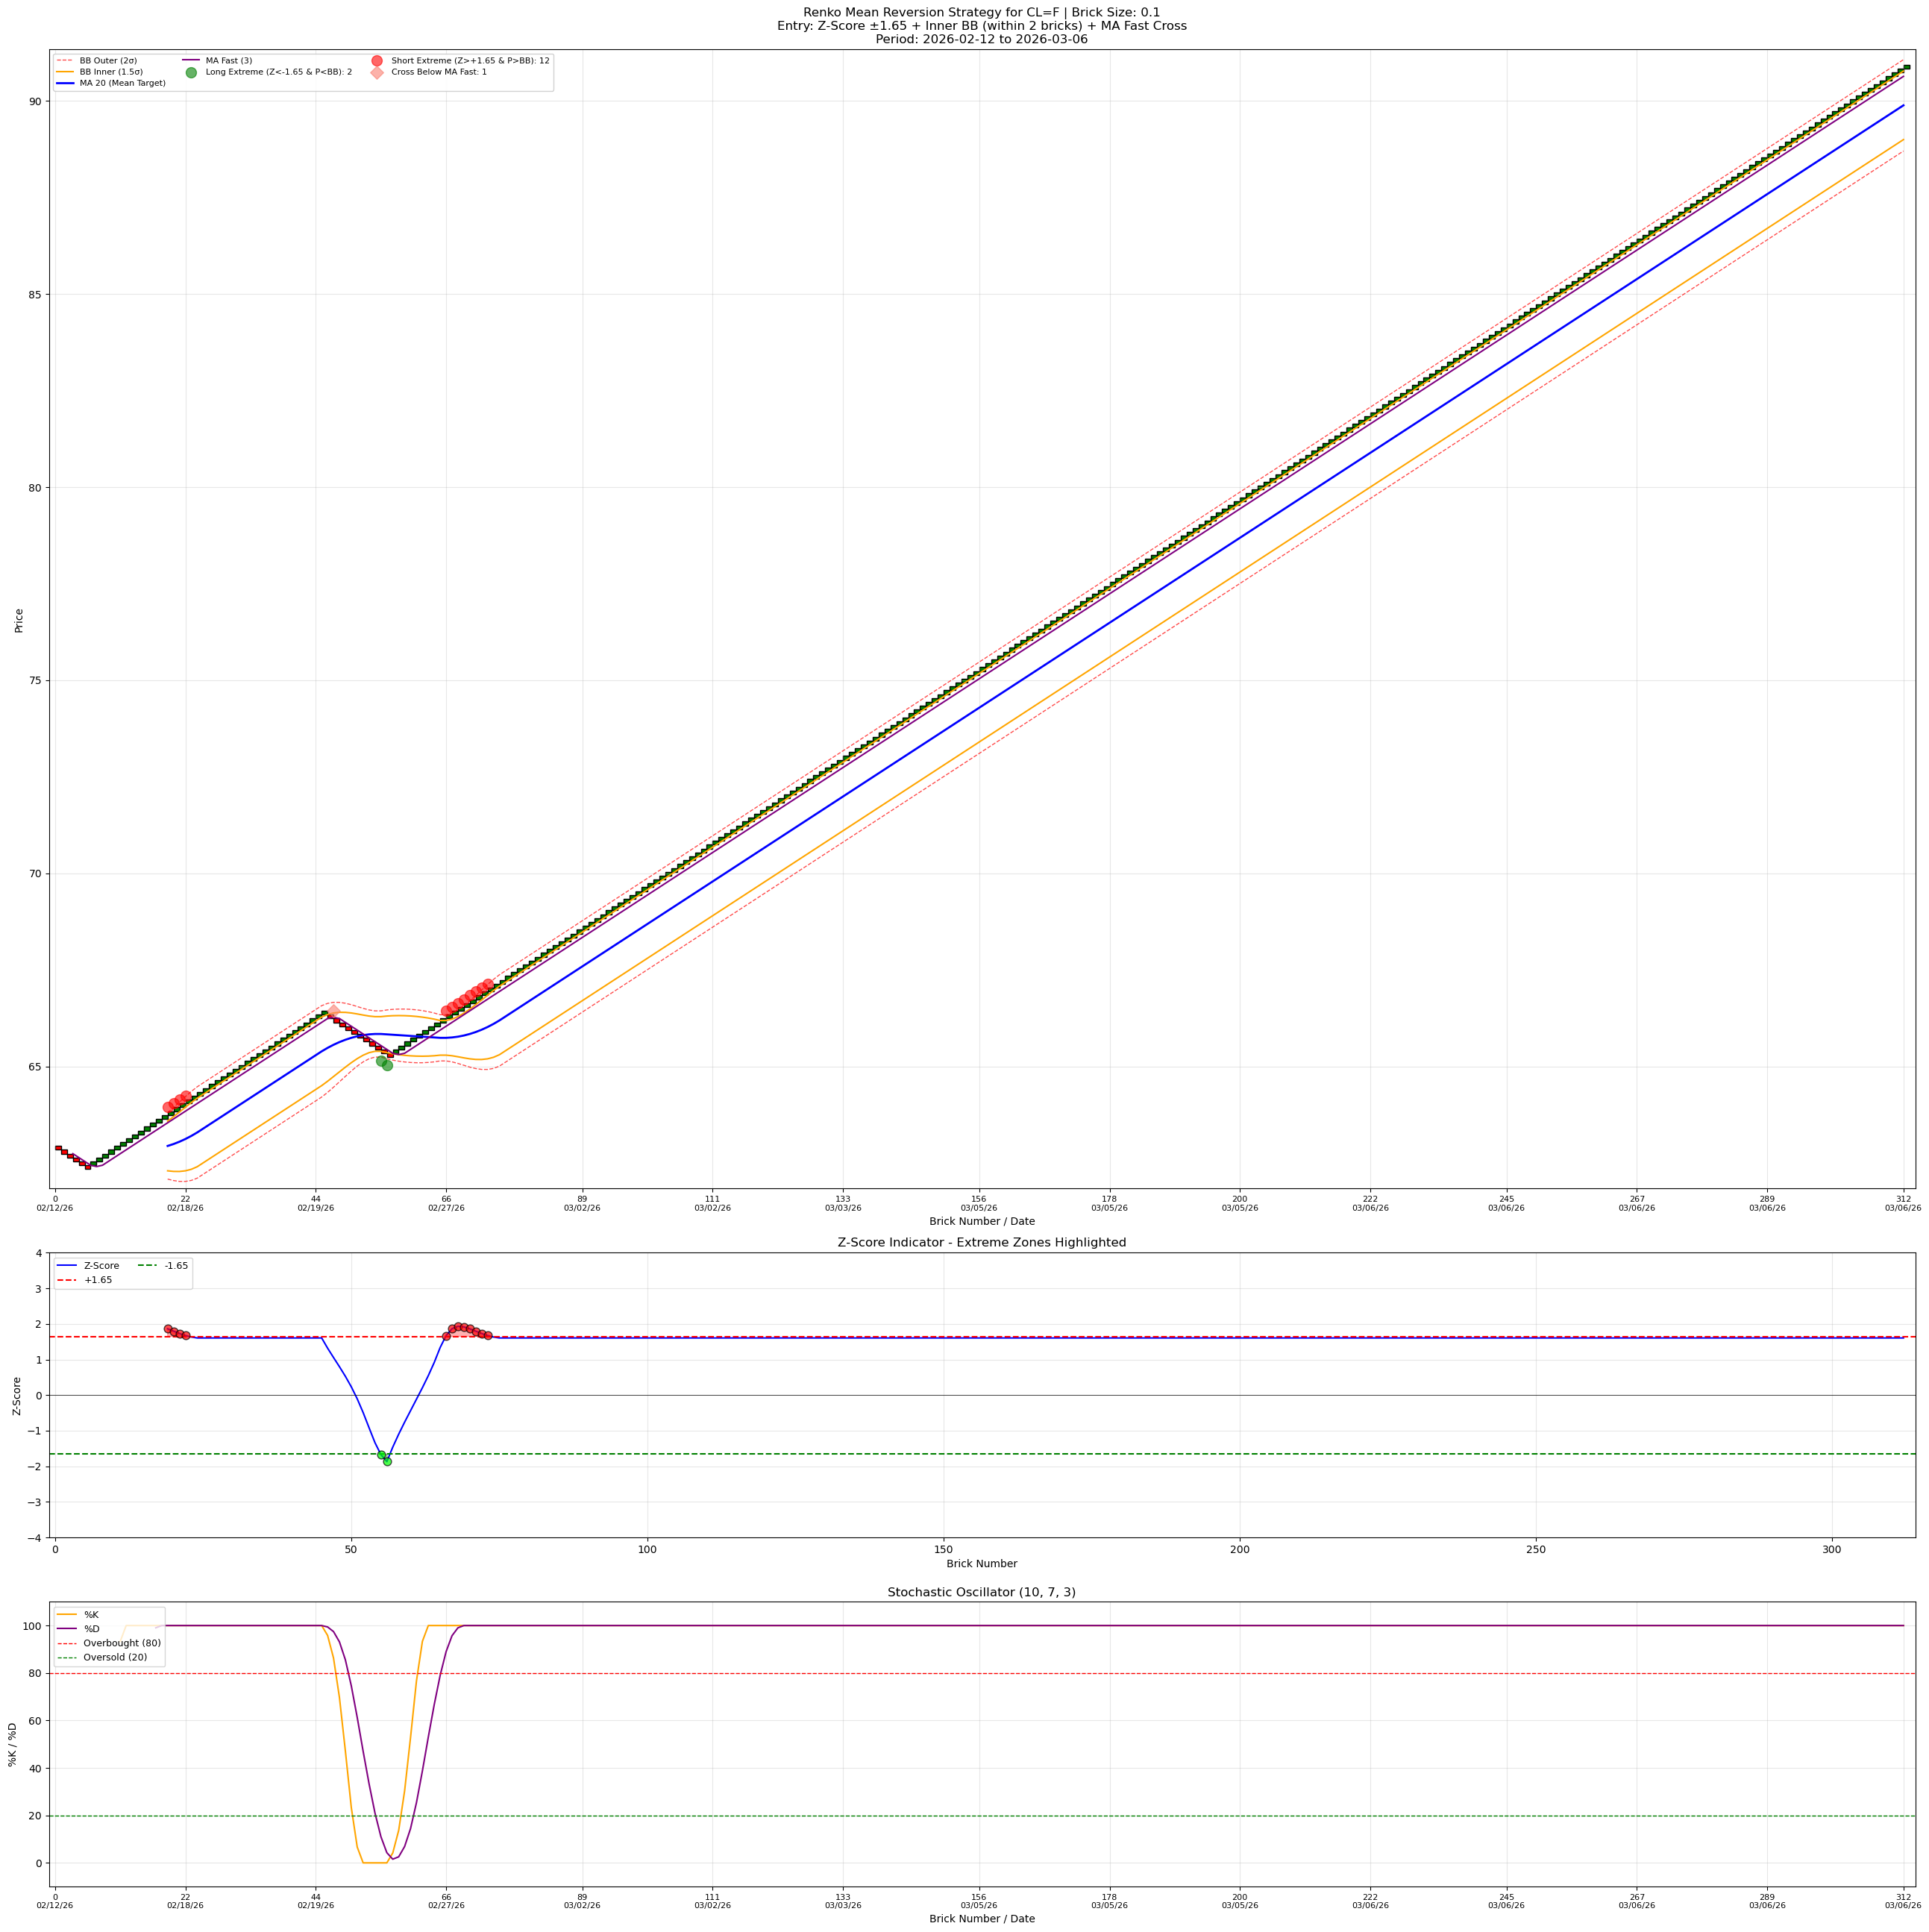

In [9]:
# Debug: Analyze entry conditions with lookback

print("=" * 80)
print("        DEBUG: Entry Conditions Analysis WITH LOOKBACK")
print("=" * 80)
print(f"Lookback Period: {ENTRY_LOOKBACK} bricks (checking current + {ENTRY_LOOKBACK} previous)")
print("-" * 80)

# Filter data where indicators are available
valid_data = renko_df.dropna(subset=['Z_Score', 'BB_Lower_Inner', 'BB_Upper_Inner', 'MA_Fast']).copy()

# --- LONG ENTRY CONDITIONS ---
print("\n--- LONG ENTRY CONDITIONS ---")

# Condition 1 & 2 combined: Z-Score < -1.65 AND Price < Inner Lower BB
long_extreme = valid_data[
    (valid_data['Z_Score'] < -Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] < valid_data['BB_Lower_Inner'])
].index.tolist()
print(f"Bricks with Z-Score < -{Z_SCORE_EXTREME_THRESHOLD} AND Price < Inner BB: {len(long_extreme)}")

# Condition 3: Price crosses above MA Fast
valid_data['Cross_Above_MA_Fast'] = (valid_data['Price_prev'] < valid_data['MA_Fast_prev']) & (valid_data['Price'] > valid_data['MA_Fast'])
long_cross = valid_data[valid_data['Cross_Above_MA_Fast'] == True].index.tolist()
print(f"Bricks with Price crossing above MA Fast: {len(long_cross)}")

# Check for entries WITH LOOKBACK
long_entries_with_lookback = []
for cross_idx in long_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in long_extreme:
            long_entries_with_lookback.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Lookback': lookback,
                'Cross_Date': renko_df.loc[cross_idx, 'Date'],
                'Z_Score': renko_df.loc[check_idx, 'Z_Score'],
                'Price_at_Cross': renko_df.loc[cross_idx, 'Price']
            })
            break  # Only count once per crossover

print(f"Potential LONG entries with lookback: {len(long_entries_with_lookback)}")

if long_entries_with_lookback:
    print("\nLong Entry Candidates:")
    long_entry_df = pd.DataFrame(long_entries_with_lookback)
    long_entry_df['Cross_Date'] = pd.to_datetime(long_entry_df['Cross_Date']).dt.strftime('%Y-%m-%d')
    display(long_entry_df)

# --- SHORT ENTRY CONDITIONS ---
print("\n--- SHORT ENTRY CONDITIONS ---")

# Condition 1 & 2 combined: Z-Score > +1.65 AND Price > Inner Upper BB
short_extreme = valid_data[
    (valid_data['Z_Score'] > Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] > valid_data['BB_Upper_Inner'])
].index.tolist()
print(f"Bricks with Z-Score > +{Z_SCORE_EXTREME_THRESHOLD} AND Price > Inner BB: {len(short_extreme)}")

# Condition 3: Price crosses below MA Fast
valid_data['Cross_Below_MA_Fast'] = (valid_data['Price_prev'] > valid_data['MA_Fast_prev']) & (valid_data['Price'] < valid_data['MA_Fast'])
short_cross = valid_data[valid_data['Cross_Below_MA_Fast'] == True].index.tolist()
print(f"Bricks with Price crossing below MA Fast: {len(short_cross)}")

# Check for entries WITH LOOKBACK
short_entries_with_lookback = []
for cross_idx in short_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in short_extreme:
            short_entries_with_lookback.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Lookback': lookback,
                'Cross_Date': renko_df.loc[cross_idx, 'Date'],
                'Z_Score': renko_df.loc[check_idx, 'Z_Score'],
                'Price_at_Cross': renko_df.loc[cross_idx, 'Price']
            })
            break

print(f"Potential SHORT entries with lookback: {len(short_entries_with_lookback)}")

if short_entries_with_lookback:
    print("\nShort Entry Candidates:")
    short_entry_df = pd.DataFrame(short_entries_with_lookback)
    short_entry_df['Cross_Date'] = pd.to_datetime(short_entry_df['Cross_Date']).dt.strftime('%Y-%m-%d')
    display(short_entry_df)

# --- NEAR MISSES ANALYSIS ---
print("\n" + "=" * 80)
print("                    NEAR MISS ANALYSIS")
print("=" * 80)

# Check crossovers that were close to extreme conditions but outside lookback
long_near_misses = []
for cross_idx in long_cross:
    # Check if there was an extreme condition within 5 bricks (beyond lookback)
    for lookback in range(ENTRY_LOOKBACK + 1, 6):
        check_idx = cross_idx - lookback
        if check_idx in long_extreme:
            long_near_misses.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Missed_By': lookback - ENTRY_LOOKBACK,
                'Cross_Date': renko_df.loc[cross_idx, 'Date']
            })
            break

print(f"\nLong Near Misses (extreme condition {ENTRY_LOOKBACK+1}-5 bricks before crossover): {len(long_near_misses)}")
if long_near_misses:
    display(pd.DataFrame(long_near_misses).head(10))

short_near_misses = []
for cross_idx in short_cross:
    for lookback in range(ENTRY_LOOKBACK + 1, 6):
        check_idx = cross_idx - lookback
        if check_idx in short_extreme:
            short_near_misses.append({
                'Cross_Brick': cross_idx,
                'Condition_Brick': check_idx,
                'Missed_By': lookback - ENTRY_LOOKBACK,
                'Cross_Date': renko_df.loc[cross_idx, 'Date']
            })
            break

print(f"\nShort Near Misses (extreme condition {ENTRY_LOOKBACK+1}-5 bricks before crossover): {len(short_near_misses)}")
if short_near_misses:
    display(pd.DataFrame(short_near_misses).head(10))

print("\n" + "=" * 80)




# ========== CALCULATE DEBUG CONDITIONS WITH LOOKBACK ==========

valid_data = renko_df.dropna(subset=['Z_Score', 'BB_Lower_Inner', 'BB_Upper_Inner', 'MA_Fast']).copy()

# --- EXTREME CONDITIONS (Z-Score + BB combined) ---
long_extreme_cond = valid_data[
    (valid_data['Z_Score'] < -Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] < valid_data['BB_Lower_Inner'])
].index.tolist()

short_extreme_cond = valid_data[
    (valid_data['Z_Score'] > Z_SCORE_EXTREME_THRESHOLD) & 
    (valid_data['Price'] > valid_data['BB_Upper_Inner'])
].index.tolist()

# --- CROSSOVER CONDITIONS ---
valid_data['Cross_Above_MA_Fast'] = (valid_data['Price_prev'] < valid_data['MA_Fast_prev']) & (valid_data['Price'] > valid_data['MA_Fast'])
valid_data['Cross_Below_MA_Fast'] = (valid_data['Price_prev'] > valid_data['MA_Fast_prev']) & (valid_data['Price'] < valid_data['MA_Fast'])

long_cross = valid_data[valid_data['Cross_Above_MA_Fast'] == True].index.tolist()
short_cross = valid_data[valid_data['Cross_Below_MA_Fast'] == True].index.tolist()

# --- POTENTIAL ENTRIES WITH LOOKBACK ---
long_potential_entries = []
for cross_idx in long_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in long_extreme_cond:
            long_potential_entries.append({
                'entry_brick': cross_idx,
                'condition_brick': check_idx,
                'lookback': lookback
            })
            break

short_potential_entries = []
for cross_idx in short_cross:
    for lookback in range(ENTRY_LOOKBACK + 1):
        check_idx = cross_idx - lookback
        if check_idx in short_extreme_cond:
            short_potential_entries.append({
                'entry_brick': cross_idx,
                'condition_brick': check_idx,
                'lookback': lookback
            })
            break

print("=" * 70)
print("                    DEBUG: CONDITIONS SUMMARY")
print("=" * 70)
print(f"\n--- LONG ---")
print(f"Extreme conditions (Z < -{Z_SCORE_EXTREME_THRESHOLD} AND Price < Inner BB): {len(long_extreme_cond)}")
print(f"MA Fast crossovers (up): {len(long_cross)}")
print(f"Potential entries (with {ENTRY_LOOKBACK}-brick lookback): {len(long_potential_entries)}")

print(f"\n--- SHORT ---")
print(f"Extreme conditions (Z > +{Z_SCORE_EXTREME_THRESHOLD} AND Price > Inner BB): {len(short_extreme_cond)}")
print(f"MA Fast crossovers (down): {len(short_cross)}")
print(f"Potential entries (with {ENTRY_LOOKBACK}-brick lookback): {len(short_potential_entries)}")
print("=" * 70)

# ========== SETUP THE PLOT ==========

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(26, 26), gridspec_kw={'height_ratios': [4, 1, 1]})

# ------------------------------------
# Subplot 1: Renko Chart with Debug Markers
# ------------------------------------

ax1.set_title(f"Renko Mean Reversion Strategy for {ticker} | Brick Size: {brick_size}\n"
              f"Entry: Z-Score ±{Z_SCORE_EXTREME_THRESHOLD} + Inner BB (within {ENTRY_LOOKBACK} bricks) + MA Fast Cross\n"
              f"Period: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}",
              fontsize=12)
ax1.set_xlabel('Brick Number / Date')
ax1.set_ylabel('Price')

# Plot each brick
for i in range(len(x_positions)):
    color = 'green' if directions[i] == 1 else 'red'
    rect = Rectangle(
        (x_positions[i], y_positions[i]), 1, brick_size,
        facecolor=color, edgecolor='black'
    )
    ax1.add_patch(rect)

# Plot Bollinger Bands
ax1.plot(x_positions, renko_df['BB_Upper_Outer'].tolist(), color='red', linewidth=1, linestyle='--', label='BB Outer (2σ)', alpha=0.7)
ax1.plot(x_positions, renko_df['BB_Lower_Outer'].tolist(), color='red', linewidth=1, linestyle='--', alpha=0.7)
ax1.plot(x_positions, renko_df['BB_Upper_Inner'].tolist(), color='orange', linewidth=1.5, label='BB Inner (1.5σ)')
ax1.plot(x_positions, renko_df['BB_Lower_Inner'].tolist(), color='orange', linewidth=1.5)

# Plot Moving Averages
ax1.plot(x_positions, renko_df['BB_Middle_Outer'].tolist(), color='blue', linewidth=2, label='MA 20 (Mean Target)')
ax1.plot(x_positions, renko_df['MA_Fast'].tolist(), color='purple', linewidth=1.5, label='MA Fast (3)')

# ========== DEBUG MARKERS ==========

# LONG Extreme Condition (Z-Score + BB combined) - Green Circle
if long_extreme_cond:
    ax1.scatter(
        [x_positions[i] for i in long_extreme_cond],
        [renko_df.loc[i, 'Price'] - brick_size * 2 for i in long_extreme_cond],
        marker='o', color='green', s=100, alpha=0.6,
        label=f'Long Extreme (Z<-{Z_SCORE_EXTREME_THRESHOLD} & P<BB): {len(long_extreme_cond)}', zorder=4
    )

# LONG MA Cross Up - Green Diamond
if long_cross:
    ax1.scatter(
        [x_positions[i] for i in long_cross],
        [renko_df.loc[i, 'Price'] - brick_size * 3 for i in long_cross],
        marker='D', color='limegreen', s=80, alpha=0.6,
        label=f'Cross Above MA Fast: {len(long_cross)}', zorder=4
    )

# SHORT Extreme Condition (Z-Score + BB combined) - Red Circle
if short_extreme_cond:
    ax1.scatter(
        [x_positions[i] for i in short_extreme_cond],
        [renko_df.loc[i, 'Price'] + brick_size * 2 for i in short_extreme_cond],
        marker='o', color='red', s=100, alpha=0.6,
        label=f'Short Extreme (Z>+{Z_SCORE_EXTREME_THRESHOLD} & P>BB): {len(short_extreme_cond)}', zorder=4
    )

# SHORT MA Cross Down - Red Diamond
if short_cross:
    ax1.scatter(
        [x_positions[i] for i in short_cross],
        [renko_df.loc[i, 'Price'] + brick_size * 3 for i in short_cross],
        marker='D', color='salmon', s=80, alpha=0.6,
        label=f'Cross Below MA Fast: {len(short_cross)}', zorder=4
    )

# Draw connection lines for LOOKBACK matches (potential entries)
for entry in long_potential_entries:
    if entry['lookback'] > 0:  # Only draw if lookback was used
        ax1.plot(
            [x_positions[entry['condition_brick']], x_positions[entry['entry_brick']]],
            [renko_df.loc[entry['condition_brick'], 'Price'] - brick_size * 2, 
             renko_df.loc[entry['entry_brick'], 'Price'] - brick_size * 3],
            color='lime', linestyle=':', linewidth=2, alpha=0.8
        )

for entry in short_potential_entries:
    if entry['lookback'] > 0:
        ax1.plot(
            [x_positions[entry['condition_brick']], x_positions[entry['entry_brick']]],
            [renko_df.loc[entry['condition_brick'], 'Price'] + brick_size * 2, 
             renko_df.loc[entry['entry_brick'], 'Price'] + brick_size * 3],
            color='magenta', linestyle=':', linewidth=2, alpha=0.8
        )

# ========== TRADE MARKERS (Actual Trades) ==========

# Plot Long Entry Points
long_entries = [t for t in trade_log if t['Type'] == 'LONG']
long_entry_bricks = [t['Entry_Brick'] for t in long_entries]
long_entry_prices = [t['Entry_Price'] for t in long_entries]

if long_entry_bricks:
    ax1.scatter(long_entry_bricks, long_entry_prices, marker='^', color='lime', s=350,
                edgecolors='black', linewidths=2, label=f'LONG ENTRY: {len(long_entry_bricks)}', zorder=7)
    
    # Draw lookback indicator for each entry
    for trade in long_entries:
        if trade.get('Lookback_Used', 0) > 0:
            ax1.annotate(
                f"↩{trade['Lookback_Used']}",
                (trade['Entry_Brick'], trade['Entry_Price']),
                textcoords="offset points", xytext=(15, -10),
                fontsize=9, color='darkgreen', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgreen', alpha=0.8)
            )

# Plot Short Entry Points
short_entries = [t for t in trade_log if t['Type'] == 'SHORT']
short_entry_bricks = [t['Entry_Brick'] for t in short_entries]
short_entry_prices = [t['Entry_Price'] for t in short_entries]

if short_entry_bricks:
    ax1.scatter(short_entry_bricks, short_entry_prices, marker='v', color='magenta', s=350,
                edgecolors='black', linewidths=2, label=f'SHORT ENTRY: {len(short_entry_bricks)}', zorder=7)
    
    # Draw lookback indicator for each entry
    for trade in short_entries:
        if trade.get('Lookback_Used', 0) > 0:
            ax1.annotate(
                f"↩{trade['Lookback_Used']}",
                (trade['Entry_Brick'], trade['Entry_Price']),
                textcoords="offset points", xytext=(15, 10),
                fontsize=9, color='darkred', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8)
            )

# Plot Scale Out Points
scale_out_bricks = [t['Scale_Out_Brick'] for t in trade_log if 'Scale_Out_Brick' in t]
scale_out_prices = [t['Scale_Out_Price'] for t in trade_log if 'Scale_Out_Price' in t]

if scale_out_bricks:
    ax1.scatter(scale_out_bricks, scale_out_prices, marker='s', color='cyan', s=200,
                edgecolors='black', linewidths=1.5, label='Scale Out (50%)', zorder=7)

# Plot Exit Points
exit_bricks = [t['Exit_Brick'] for t in trade_log if 'Exit_Brick' in t]
exit_prices = [t['Exit_Price'] for t in trade_log if 'Exit_Price' in t]

if exit_bricks:
    ax1.scatter(exit_bricks, exit_prices, marker='x', color='yellow', s=250,
                linewidths=3, label='Full Exit', zorder=7)

# Plot Stop Loss Lines
for trade in trade_log:
    if 'Stop_Loss' in trade:
        entry_brick = trade['Entry_Brick']
        exit_brick = trade.get('Exit_Brick', entry_brick + 20)
        stop_loss = trade['Stop_Loss']
        ax1.plot([entry_brick, exit_brick], [stop_loss, stop_loss], 
                 color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Draw lines connecting entry to exit
for trade in trade_log:
    if 'Exit_Brick' in trade:
        pnl = trade.get('PnL', 0)
        line_color = 'cyan' if pnl > 0 else 'orange'
        ax1.plot([trade['Entry_Brick'], trade['Exit_Brick']],
                 [trade['Entry_Price'], trade['Exit_Price']],
                 color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# Set axis limits
ax1.set_xlim(-1, max(x_positions) + 2)
ax1.set_ylim(min(y_positions) - brick_size * 5, max(y_positions) + brick_size * 5)

# X-axis with dates
num_ticks = 15
tick_indices = np.linspace(0, len(x_positions) - 1, num_ticks, dtype=int)
tick_labels = [f"{x_positions[i]}\n{renko_df.loc[i, 'Date'].strftime('%m/%d/%y')}" for i in tick_indices]
ax1.set_xticks([x_positions[i] for i in tick_indices])
ax1.set_xticklabels(tick_labels, fontsize=8)

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=8, ncol=3, framealpha=0.9)

# ------------------------------------
# Subplot 2: Z-Score with Extreme Zones
# ------------------------------------

ax2.set_title("Z-Score Indicator - Extreme Zones Highlighted", fontsize=12)
ax2.set_xlabel('Brick Number')
ax2.set_ylabel('Z-Score')

ax2.plot(x_positions, renko_df['Z_Score'].tolist(), label='Z-Score', color='blue', linewidth=1.5)
ax2.axhline(Z_SCORE_EXTREME_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'+{Z_SCORE_EXTREME_THRESHOLD}')
ax2.axhline(-Z_SCORE_EXTREME_THRESHOLD, color='green', linestyle='--', linewidth=1.5, label=f'-{Z_SCORE_EXTREME_THRESHOLD}')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)

# Fill extreme zones
z_scores = renko_df['Z_Score'].tolist()
ax2.fill_between(x_positions, Z_SCORE_EXTREME_THRESHOLD, z_scores, 
                  where=[z > Z_SCORE_EXTREME_THRESHOLD if not pd.isna(z) else False for z in z_scores], 
                  color='red', alpha=0.3)
ax2.fill_between(x_positions, -Z_SCORE_EXTREME_THRESHOLD, z_scores, 
                  where=[z < -Z_SCORE_EXTREME_THRESHOLD if not pd.isna(z) else False for z in z_scores], 
                  color='green', alpha=0.3)

# Mark extreme + BB conditions (combined)
if long_extreme_cond:
    ax2.scatter([x_positions[i] for i in long_extreme_cond],
                [renko_df.loc[i, 'Z_Score'] for i in long_extreme_cond],
                marker='o', color='lime', s=60, edgecolors='black', alpha=0.7, zorder=4)

if short_extreme_cond:
    ax2.scatter([x_positions[i] for i in short_extreme_cond],
                [renko_df.loc[i, 'Z_Score'] for i in short_extreme_cond],
                marker='o', color='red', s=60, edgecolors='black', alpha=0.7, zorder=4)

# Mark actual entries
if long_entry_bricks:
    ax2.scatter(long_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in long_entry_bricks],
                marker='^', color='lime', s=150, edgecolors='black', linewidths=2, zorder=5)

if short_entry_bricks:
    ax2.scatter(short_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in short_entry_bricks],
                marker='v', color='magenta', s=150, edgecolors='black', linewidths=2, zorder=5)

ax2.set_xlim(-1, max(x_positions) + 2)
ax2.set_ylim(-4, 4)
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

# ------------------------------------
# Subplot 3: Stochastic Oscillator
# ------------------------------------

ax3.set_title(f"Stochastic Oscillator ({STOCHASTIC_K_PERIOD}, {STOCHASTIC_D_PERIOD}, {STOCHASTIC_SMOOTHING_PERIOD})", fontsize=12)
ax3.set_xlabel('Brick Number / Date')
ax3.set_ylabel('%K / %D')

ax3.plot(x_positions, renko_df['%K'].tolist(), label='%K', color='orange', linewidth=1.5)
ax3.plot(x_positions, renko_df['%D'].tolist(), label='%D', color='purple', linewidth=1.5)

ax3.axhline(STOCHASTIC_EXIT_LEVEL_SHORT, color='red', linestyle='--', linewidth=1, label=f'Overbought ({STOCHASTIC_EXIT_LEVEL_SHORT})')
ax3.axhline(STOCHASTIC_EXIT_LEVEL_LONG, color='green', linestyle='--', linewidth=1, label=f'Oversold ({STOCHASTIC_EXIT_LEVEL_LONG})')

if long_entry_bricks:
    ax3.scatter(long_entry_bricks, [renko_df.loc[i, '%K'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax3.scatter(short_entry_bricks, [renko_df.loc[i, '%K'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

if exit_bricks:
    ax3.scatter(exit_bricks, [renko_df.loc[i, '%K'] for i in exit_bricks],
                marker='x', color='yellow', s=100, linewidths=2, zorder=5)

ax3.set_xlim(-1, max(x_positions) + 2)
ax3.set_ylim(-10, 110)
ax3.set_xticks([x_positions[i] for i in tick_indices])
ax3.set_xticklabels(tick_labels, fontsize=8)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

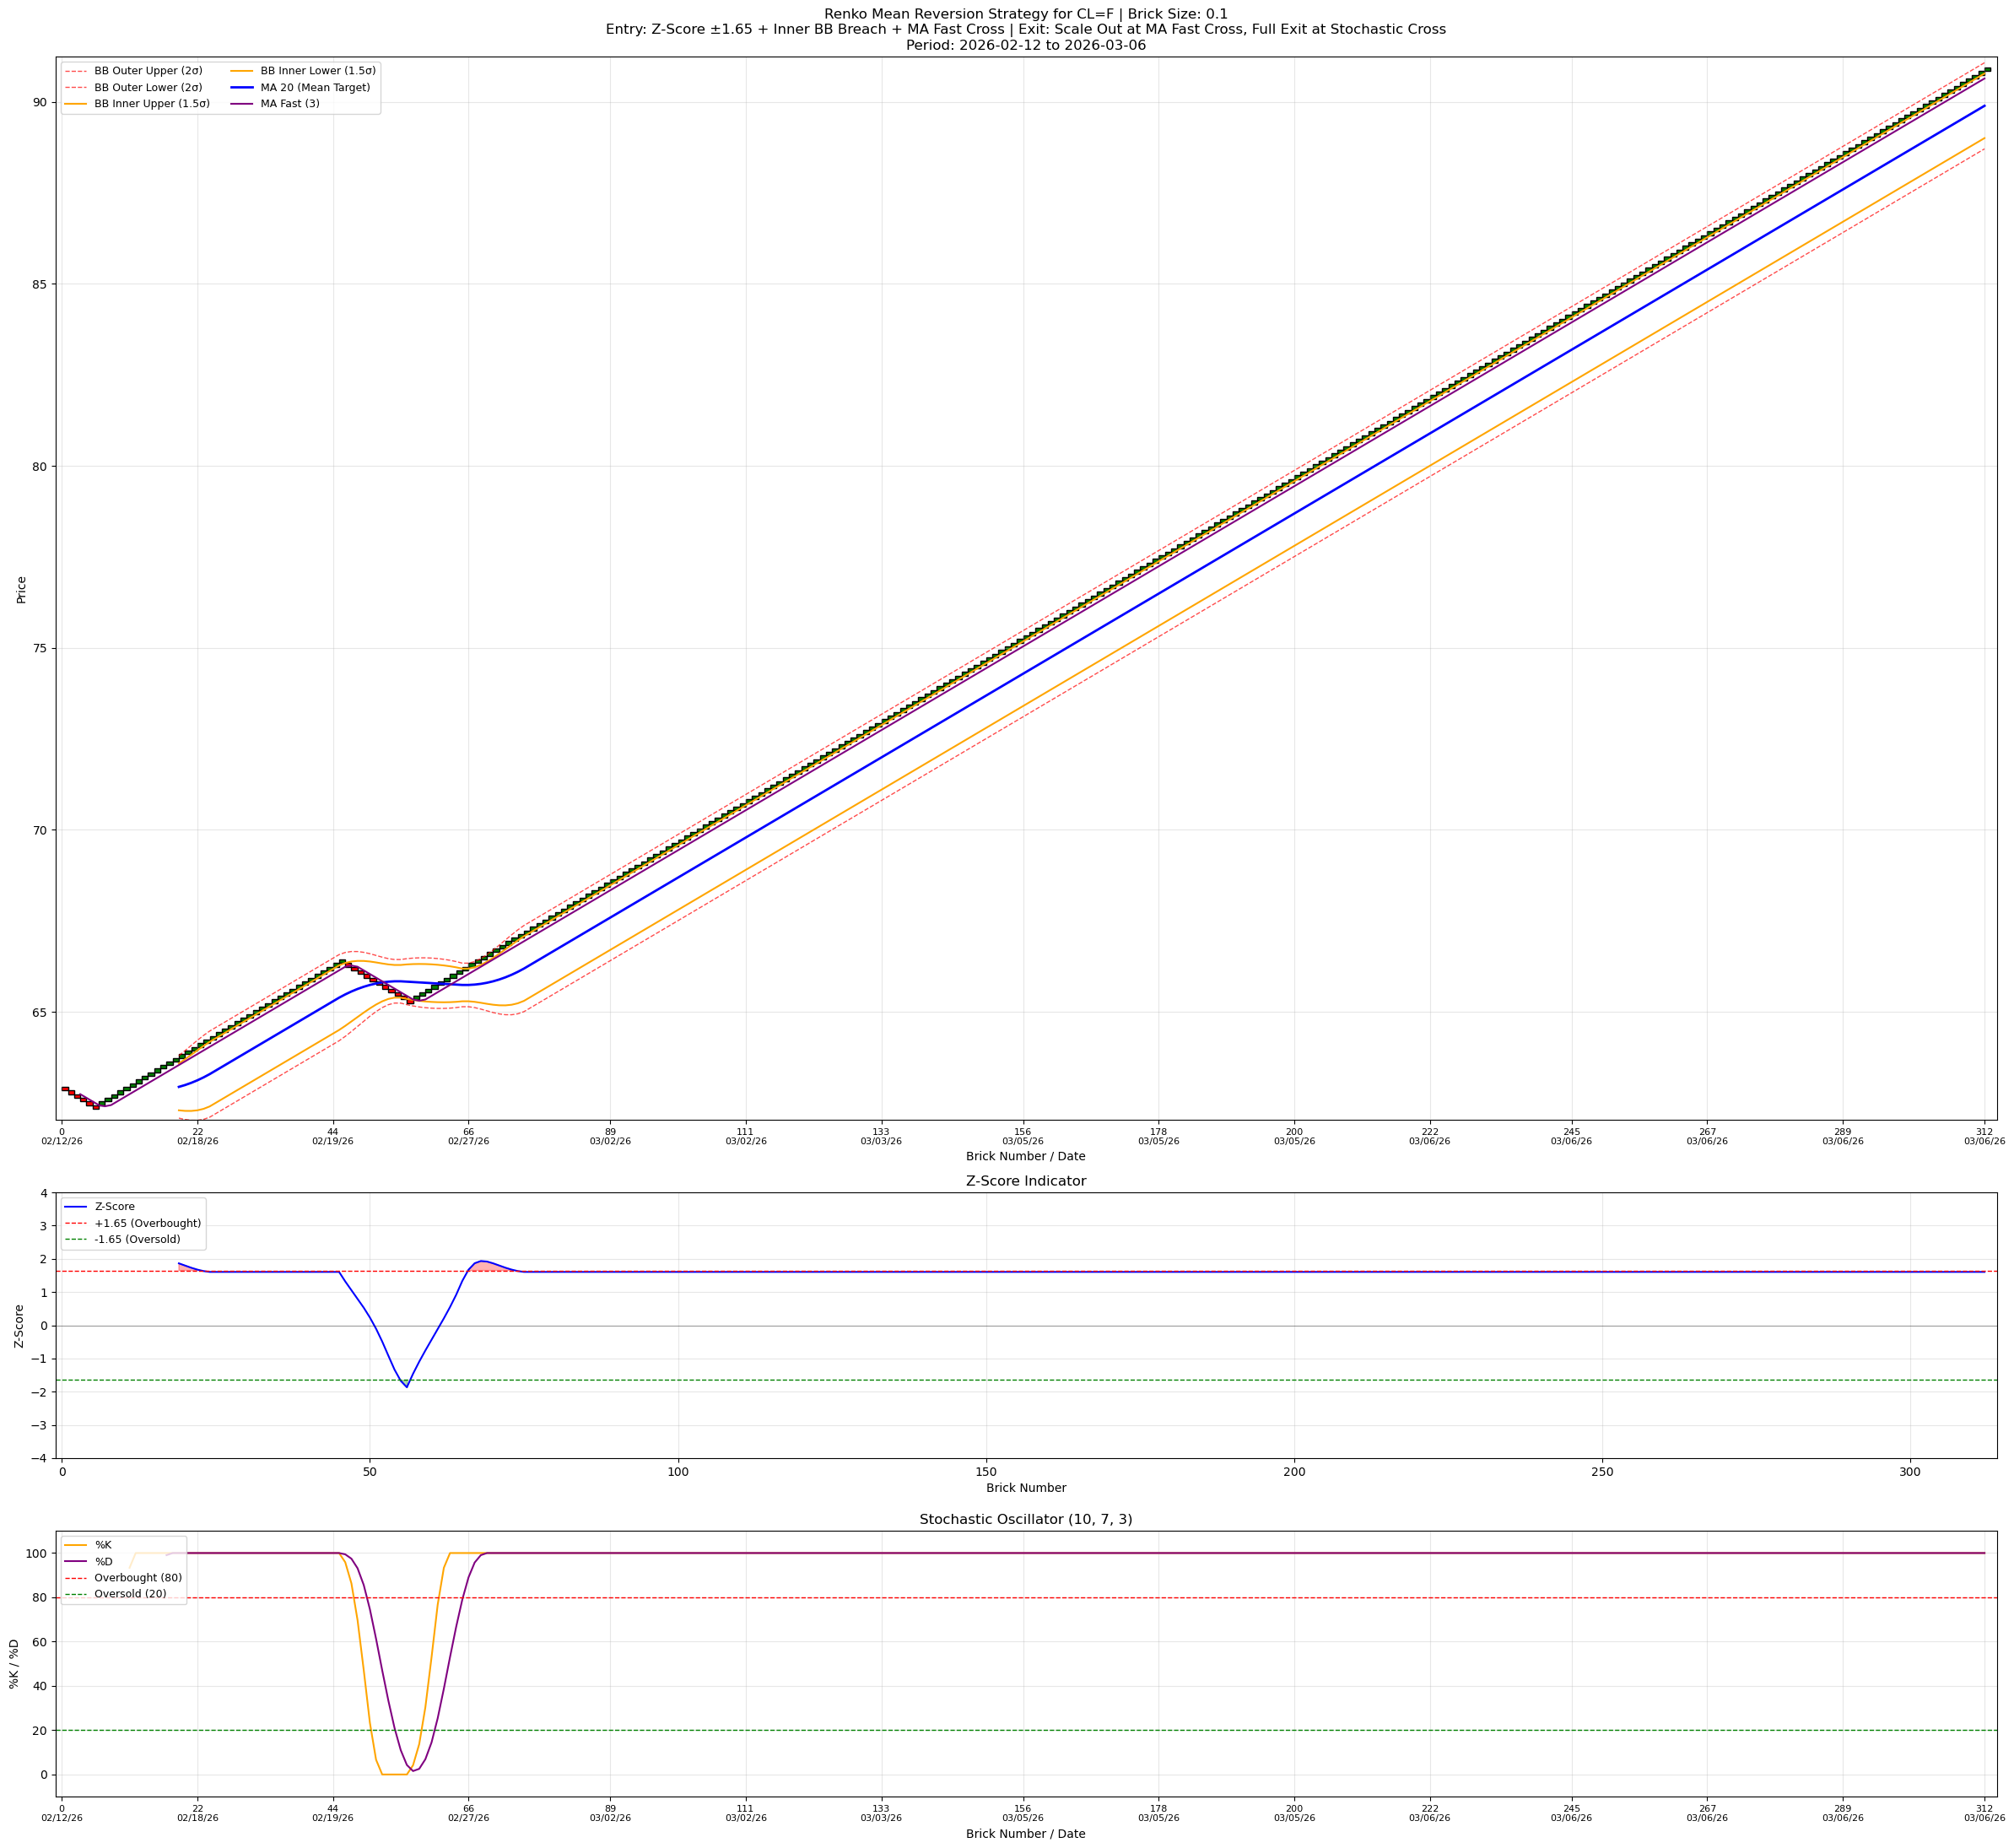

In [10]:
# Setup the plot with three subplots: Renko, Z-Score, and Stochastic
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(24, 22), gridspec_kw={'height_ratios': [4, 1, 1]})

# ------------------------------------
# Subplot 1: Renko Chart with Bollinger Bands and Trades
# ------------------------------------

ax1.set_title(f"Renko Mean Reversion Strategy for {ticker} | Brick Size: {brick_size}\n"
              f"Entry: Z-Score ±{Z_SCORE_EXTREME_THRESHOLD} + Inner BB Breach + MA Fast Cross | "
              f"Exit: Scale Out at MA Fast Cross, Full Exit at Stochastic Cross\n"
              f"Period: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}",
              fontsize=12)
ax1.set_xlabel('Brick Number / Date')
ax1.set_ylabel('Price')

# Plot each brick
for i in range(len(x_positions)):
    color = 'green' if directions[i] == 1 else 'red'
    rect = Rectangle(
        (x_positions[i], y_positions[i]), 1, brick_size,
        facecolor=color, edgecolor='black'
    )
    ax1.add_patch(rect)

# Plot Bollinger Bands (Outer)
ax1.plot(x_positions, renko_df['BB_Upper_Outer'].tolist(), color='red', linewidth=1, linestyle='--', label='BB Outer Upper (2σ)', alpha=0.7)
ax1.plot(x_positions, renko_df['BB_Lower_Outer'].tolist(), color='red', linewidth=1, linestyle='--', label='BB Outer Lower (2σ)', alpha=0.7)

# Plot Bollinger Bands (Inner)
ax1.plot(x_positions, renko_df['BB_Upper_Inner'].tolist(), color='orange', linewidth=1.5, label='BB Inner Upper (1.5σ)')
ax1.plot(x_positions, renko_df['BB_Lower_Inner'].tolist(), color='orange', linewidth=1.5, label='BB Inner Lower (1.5σ)')

# Plot Moving Averages
ax1.plot(x_positions, renko_df['BB_Middle_Outer'].tolist(), color='blue', linewidth=2, label='MA 20 (Mean Target)')
ax1.plot(x_positions, renko_df['MA_Fast'].tolist(), color='purple', linewidth=1.5, label='MA Fast (3)')

# Plot Long Entry Points
long_entries = [t for t in trade_log if t['Type'] == 'LONG']
long_entry_bricks = [t['Entry_Brick'] for t in long_entries]
long_entry_prices = [t['Entry_Price'] for t in long_entries]

if long_entry_bricks:
    ax1.scatter(long_entry_bricks, long_entry_prices, marker='^', color='lime', s=200,
                edgecolors='black', linewidths=1.5, label='Long Entry', zorder=5)

# Plot Short Entry Points
short_entries = [t for t in trade_log if t['Type'] == 'SHORT']
short_entry_bricks = [t['Entry_Brick'] for t in short_entries]
short_entry_prices = [t['Entry_Price'] for t in short_entries]

if short_entry_bricks:
    ax1.scatter(short_entry_bricks, short_entry_prices, marker='v', color='magenta', s=200,
                edgecolors='black', linewidths=1.5, label='Short Entry', zorder=5)

# Plot Scale Out Points
scale_out_bricks = [t['Scale_Out_Brick'] for t in trade_log if 'Scale_Out_Brick' in t]
scale_out_prices = [t['Scale_Out_Price'] for t in trade_log if 'Scale_Out_Price' in t]

if scale_out_bricks:
    ax1.scatter(scale_out_bricks, scale_out_prices, marker='s', color='cyan', s=150,
                edgecolors='black', linewidths=1.5, label='Scale Out (50%)', zorder=5)

# Plot Exit Points
exit_bricks = [t['Exit_Brick'] for t in trade_log if 'Exit_Brick' in t]
exit_prices = [t['Exit_Price'] for t in trade_log if 'Exit_Price' in t]

if exit_bricks:
    ax1.scatter(exit_bricks, exit_prices, marker='x', color='yellow', s=200,
                linewidths=3, label='Full Exit', zorder=5)

# Plot Stop Loss Lines
for trade in trade_log:
    if 'Stop_Loss' in trade:
        entry_brick = trade['Entry_Brick']
        exit_brick = trade.get('Exit_Brick', entry_brick + 20)
        stop_loss = trade['Stop_Loss']
        ax1.plot([entry_brick, exit_brick], [stop_loss, stop_loss], 
                 color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Draw lines connecting entry to exit
for trade in trade_log:
    if 'Exit_Brick' in trade:
        pnl = trade.get('PnL', 0)
        line_color = 'cyan' if pnl > 0 else 'orange'
        ax1.plot([trade['Entry_Brick'], trade['Exit_Brick']],
                 [trade['Entry_Price'], trade['Exit_Price']],
                 color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# Add date annotations for trades
for trade in trade_log:
    entry_date = trade.get('Entry_Date')
    if entry_date:
        ax1.annotate(entry_date.strftime('%m/%d'),
                     (trade['Entry_Brick'], trade['Entry_Price']),
                     textcoords="offset points", xytext=(0, 15),
                     fontsize=7, ha='center', color='black',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Set axis limits
ax1.set_xlim(-1, max(x_positions) + 2)
ax1.set_ylim(min(y_positions) - brick_size * 3, max(y_positions) + brick_size * 4)

# X-axis with dates
num_ticks = 15
tick_indices = np.linspace(0, len(x_positions) - 1, num_ticks, dtype=int)
tick_labels = [f"{x_positions[i]}\n{renko_df.loc[i, 'Date'].strftime('%m/%d/%y')}" for i in tick_indices]
ax1.set_xticks([x_positions[i] for i in tick_indices])
ax1.set_xticklabels(tick_labels, fontsize=8)

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=9, ncol=2)

# ------------------------------------
# Subplot 2: Z-Score
# ------------------------------------

ax2.set_title("Z-Score Indicator", fontsize=12)
ax2.set_xlabel('Brick Number')
ax2.set_ylabel('Z-Score')

ax2.plot(x_positions, renko_df['Z_Score'].tolist(), label='Z-Score', color='blue', linewidth=1.5)
ax2.axhline(Z_SCORE_EXTREME_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'+{Z_SCORE_EXTREME_THRESHOLD} (Overbought)')
ax2.axhline(-Z_SCORE_EXTREME_THRESHOLD, color='green', linestyle='--', linewidth=1, label=f'-{Z_SCORE_EXTREME_THRESHOLD} (Oversold)')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Fill extreme zones
ax2.fill_between(x_positions, Z_SCORE_EXTREME_THRESHOLD, renko_df['Z_Score'].tolist(), 
                  where=[z > Z_SCORE_EXTREME_THRESHOLD for z in renko_df['Z_Score']], 
                  color='red', alpha=0.3)
ax2.fill_between(x_positions, -Z_SCORE_EXTREME_THRESHOLD, renko_df['Z_Score'].tolist(), 
                  where=[z < -Z_SCORE_EXTREME_THRESHOLD for z in renko_df['Z_Score']], 
                  color='green', alpha=0.3)

# Mark entry points on Z-Score
if long_entry_bricks:
    ax2.scatter(long_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax2.scatter(short_entry_bricks, [renko_df.loc[i, 'Z_Score'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

ax2.set_xlim(-1, max(x_positions) + 2)
ax2.set_ylim(-4, 4)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# ------------------------------------
# Subplot 3: Stochastic Oscillator
# ------------------------------------

ax3.set_title(f"Stochastic Oscillator ({STOCHASTIC_K_PERIOD}, {STOCHASTIC_D_PERIOD}, {STOCHASTIC_SMOOTHING_PERIOD})", fontsize=12)
ax3.set_xlabel('Brick Number / Date')
ax3.set_ylabel('%K / %D')

ax3.plot(x_positions, renko_df['%K'].tolist(), label='%K', color='orange', linewidth=1.5)
ax3.plot(x_positions, renko_df['%D'].tolist(), label='%D', color='purple', linewidth=1.5)

ax3.axhline(STOCHASTIC_EXIT_LEVEL_SHORT, color='red', linestyle='--', linewidth=1, label=f'Overbought ({STOCHASTIC_EXIT_LEVEL_SHORT})')
ax3.axhline(STOCHASTIC_EXIT_LEVEL_LONG, color='green', linestyle='--', linewidth=1, label=f'Oversold ({STOCHASTIC_EXIT_LEVEL_LONG})')

# Mark entry/exit points
if long_entry_bricks:
    ax3.scatter(long_entry_bricks, [renko_df.loc[i, '%K'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax3.scatter(short_entry_bricks, [renko_df.loc[i, '%K'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

if exit_bricks:
    ax3.scatter(exit_bricks, [renko_df.loc[i, '%K'] for i in exit_bricks],
                marker='x', color='yellow', s=100, linewidths=2, zorder=5)

ax3.set_xlim(-1, max(x_positions) + 2)
ax3.set_ylim(-10, 110)
ax3.set_xticks([x_positions[i] for i in tick_indices])
ax3.set_xticklabels(tick_labels, fontsize=8)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Display trade log as DataFrame
if trade_log:
    trade_log_df = pd.DataFrame(trade_log)
    
    # Format dates
    if 'Entry_Date' in trade_log_df.columns:
        trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date']).dt.strftime('%Y-%m-%d')
    if 'Exit_Date' in trade_log_df.columns:
        trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date']).dt.strftime('%Y-%m-%d')
    if 'Scale_Out_Date' in trade_log_df.columns:
        trade_log_df['Scale_Out_Date'] = pd.to_datetime(trade_log_df['Scale_Out_Date']).dt.strftime('%Y-%m-%d')
    
    # Add profit/loss indicator
    trade_log_df['Result'] = trade_log_df['PnL'].apply(
        lambda x: '✅ WIN' if x > 0 else ('❌ LOSS' if x < 0 else '➖ BE') if pd.notna(x) else '⏳ OPEN'
    )
    
    # Format R:R ratio
    if 'RR_Ratio' in trade_log_df.columns:
        trade_log_df['R:R'] = trade_log_df['RR_Ratio'].apply(lambda x: f"{x:.2f}R" if pd.notna(x) else "N/A")
    
    # Format Z-Score
    if 'Z_Score_Entry' in trade_log_df.columns:
        trade_log_df['Z_Score'] = trade_log_df['Z_Score_Entry'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "N/A")
    
    # Reorder columns
    cols = ['Type', 'Entry_Date', 'Entry_Brick', 'Entry_Price', 'Z_Score', 'Stop_Loss',
            'Scale_Out_Date', 'Scale_Out_Price', 'Scale_Out_PnL',
            'Exit_Date', 'Exit_Brick', 'Exit_Price', 'Exit_Type',
            'Size', 'PnL', 'R:R', 'Capital', 'Result']
    cols = [c for c in cols if c in trade_log_df.columns]
    trade_log_df = trade_log_df[cols]
    
    display(trade_log_df)
    
    # Summary by trade type
    print("\n" + "=" * 70)
    print("                    TRADE SUMMARY BY TYPE")
    print("=" * 70)
    
    for trade_type in ['LONG', 'SHORT']:
        type_trades = [t for t in trade_log if t['Type'] == trade_type and 'PnL' in t]
        if type_trades:
            type_pnl = sum(t['PnL'] for t in type_trades)
            type_wins = len([t for t in type_trades if t['PnL'] > 0])
            type_losses = len([t for t in type_trades if t['PnL'] < 0])
            type_win_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) > 0 and 'RR_Ratio' in t]
            type_loss_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) < 0 and 'RR_Ratio' in t]
            
            print(f"\n{trade_type} Trades:")
            print(f"  Total: {len(type_trades)}")
            print(f"  Wins: {type_wins} | Losses: {type_losses}")
            print(f"  Win Rate: {type_wins/len(type_trades)*100:.1f}%" if type_trades else "  Win Rate: N/A")
            print(f"  Total PnL: ${type_pnl:,.2f}")
            print(f"  Avg Winning R:R: {np.mean(type_win_rr):.2f}R" if type_win_rr else "  Avg Winning R:R: N/A")
            print(f"  Avg Losing R:R: {np.mean(type_loss_rr):.2f}R" if type_loss_rr else "  Avg Losing R:R: N/A")
        else:
            print(f"\n{trade_type} Trades: None")
    
    # Exit Type Analysis
    print("\n" + "=" * 70)
    print("                    EXIT TYPE ANALYSIS")
    print("=" * 70)
    
    exit_types = {}
    for trade in trade_log:
        if 'Exit_Type' in trade:
            exit_type = trade['Exit_Type']
            if exit_type not in exit_types:
                exit_types[exit_type] = {'count': 0, 'pnl': 0}
            exit_types[exit_type]['count'] += 1
            exit_types[exit_type]['pnl'] += trade.get('PnL', 0)
    
    for exit_type, stats in exit_types.items():
        print(f"\n{exit_type}:")
        print(f"  Count: {stats['count']}")
        print(f"  Total PnL: ${stats['pnl']:,.2f}")
    
    
else:
    print("No trades executed.")

No trades executed.


      STRATEGY PERFORMANCE METRICS (FULL DATASET)
Initial Capital:        $10,000.00
Final Capital:          $10,000.00
Total Return:           0.00%
Sharpe Ratio:           0.00
Max Drawdown:           0.00%
------------------------------------------------------------
Total Trades:           0
  - Long Trades:        0
  - Short Trades:       0
------------------------------------------------------------
Overall Win Rate:       0.00%
Long Win Rate:          0.00%
Short Win Rate:         0.00%
Profit Factor:          inf
------------------------------------------------------------
Average Win:            $0.00
Average Loss:           $0.00
------------------------------------------------------------
              STREAK ANALYSIS
------------------------------------------------------------
Max Winning Streak:     0 trades
Max Losing Streak:      0 trades
------------------------------------------------------------
            RISK-REWARD ANALYSIS
----------------------------------------

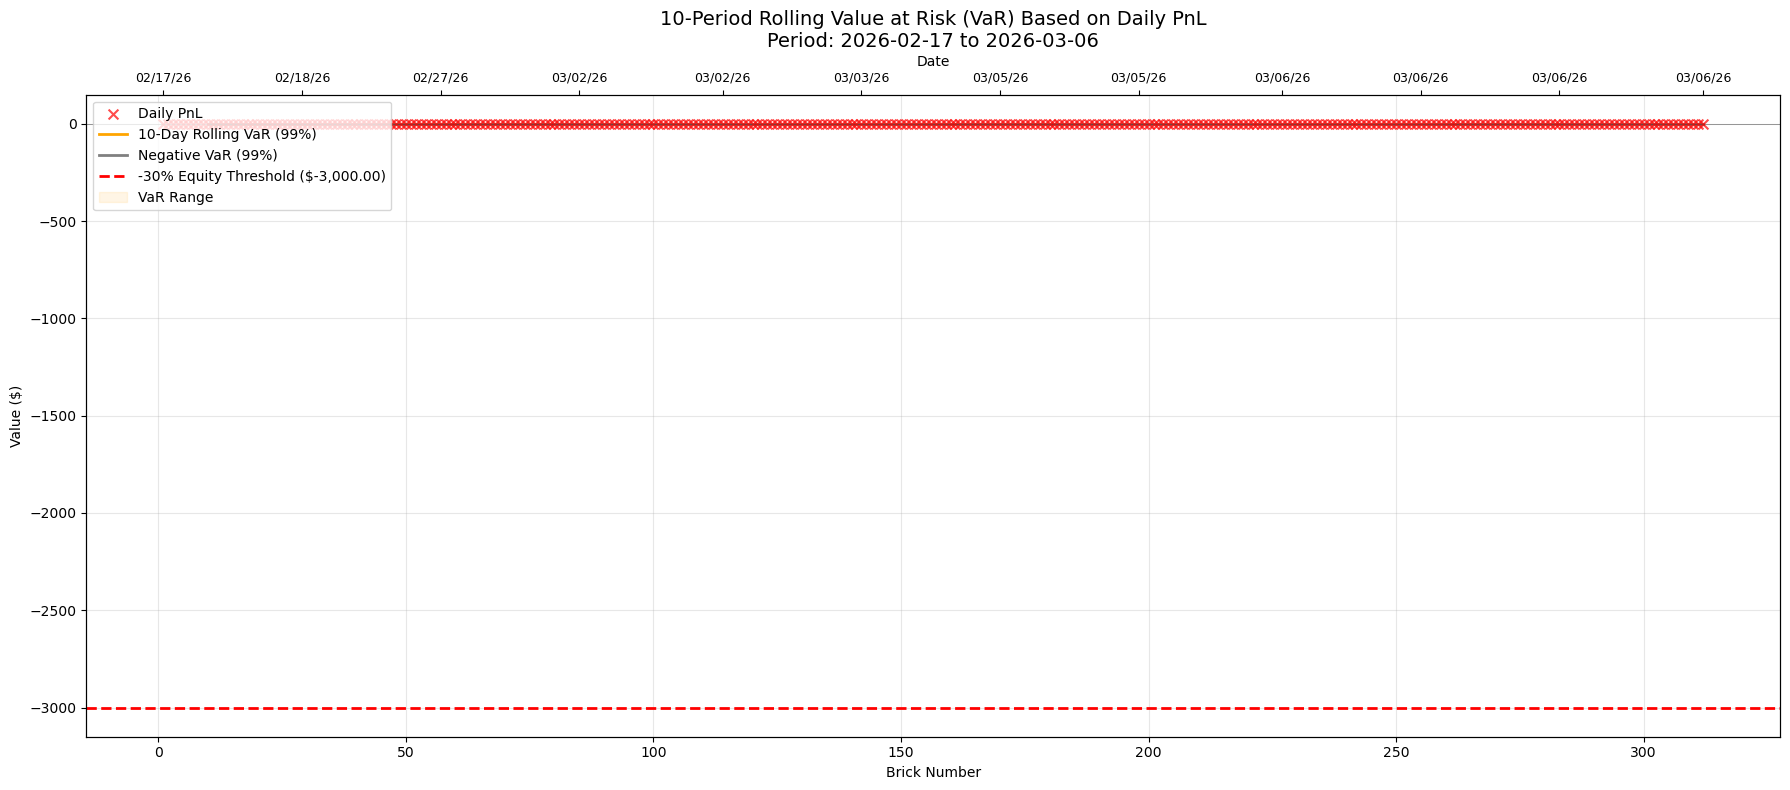

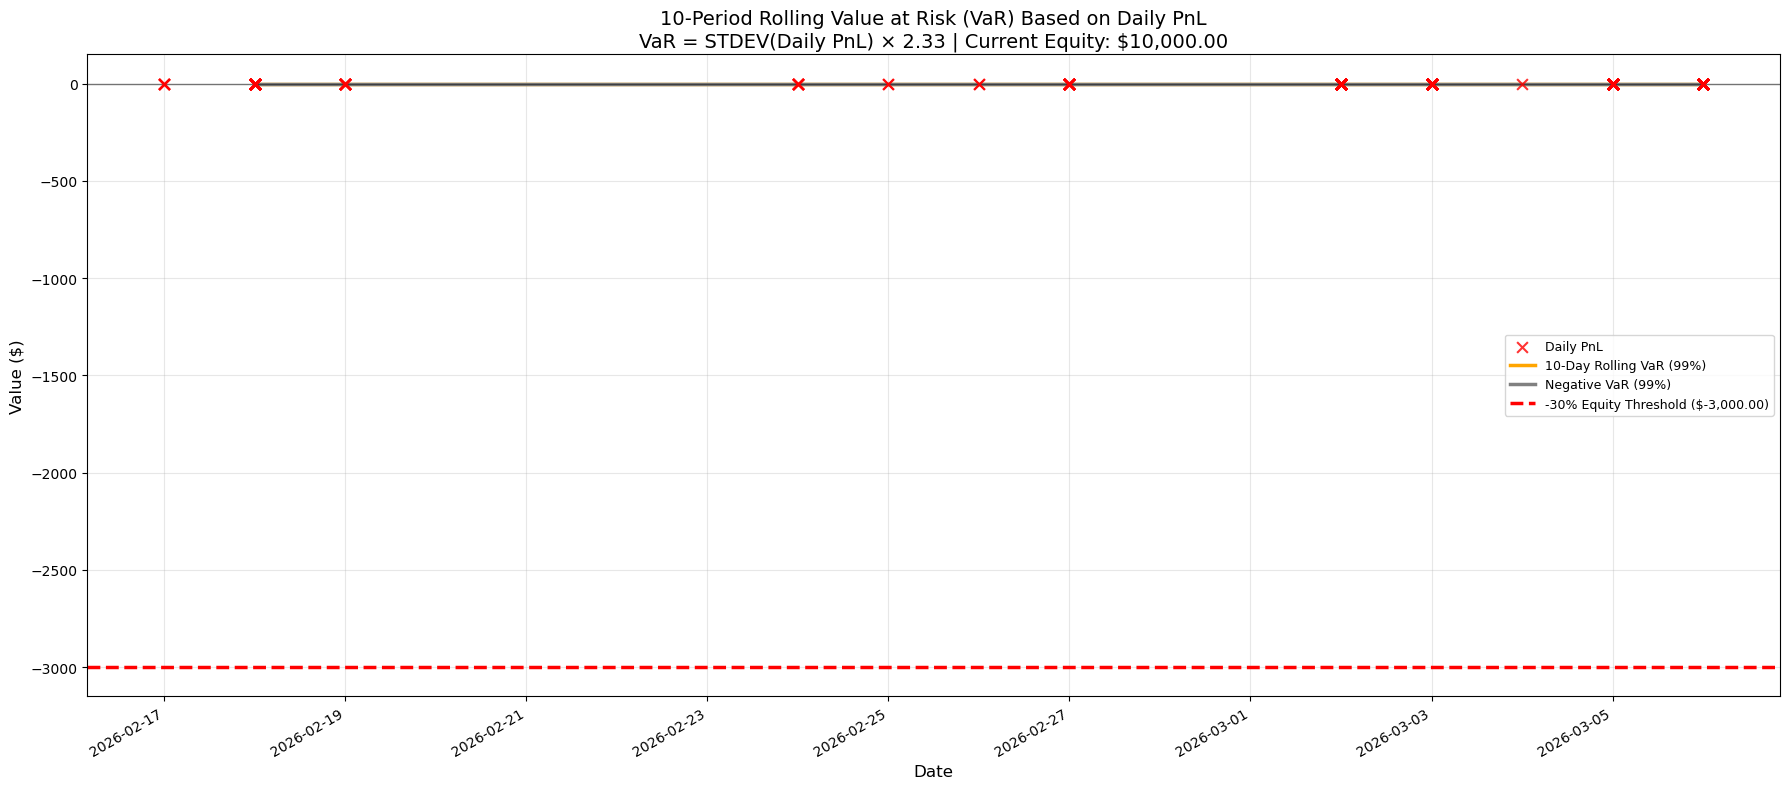


           VaR BREACH ANALYSIS
Total Daily PnL Observations:  312
VaR Breaches (Positive):       0
VaR Breaches (Negative):       0
Breach Rate:                   0.00%
Expected Breach Rate (99%):    1.00%


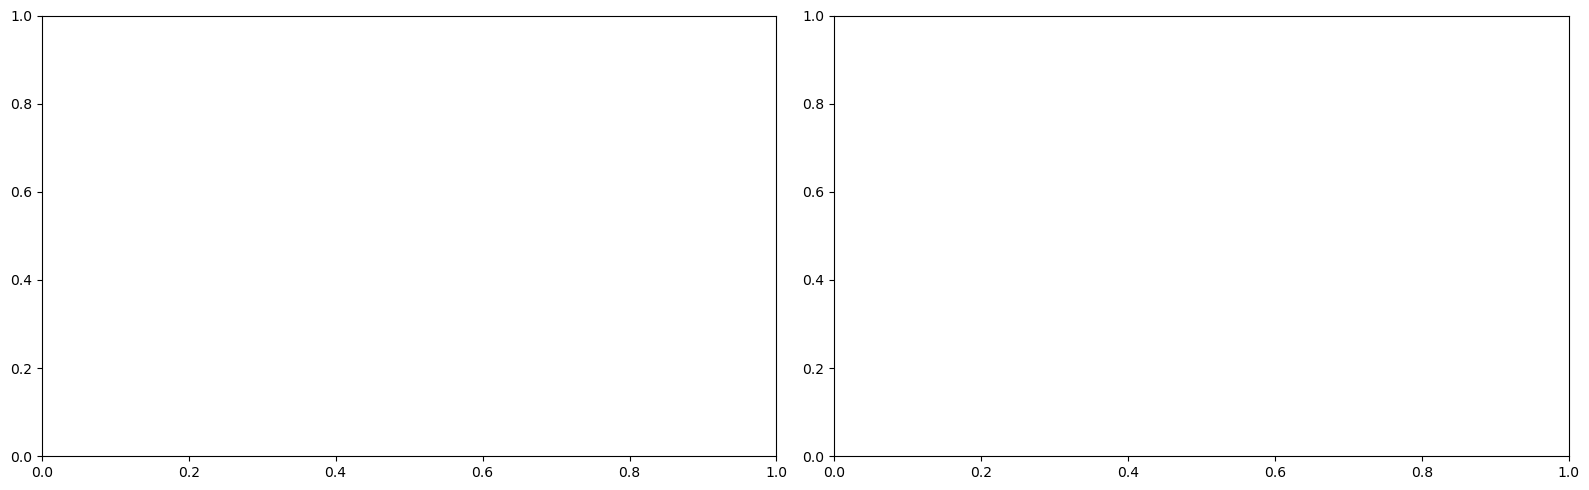


           DAILY PnL STATISTICS
Total Observations:     312
Non-Zero PnL Days:      0
Mean Daily PnL: N/A
Std Dev Daily PnL: N/A
Max Daily Gain: N/A
Max Daily Loss: N/A


In [12]:
## 8. Calculate Performance Metrics (Full Dataset)

#Includes:
#- Basic metrics (Return, Sharpe, Drawdown)
#- Win/Loss streaks
#- Risk-Reward ratios
#- Value at Risk (VaR)

# Ensure equity_curve has values
if len(equity_curve) == 0:
    equity_curve = [initial_capital]
if len(cumulative_pnl) == 0:
    cumulative_pnl = [0]

# Convert to numpy arrays
equity_array = np.array(equity_curve)
cumulative_pnl_array = np.array(cumulative_pnl)

# ========== BASIC METRICS ==========

# Returns (simple)
if len(equity_array) > 1:
    returns = np.diff(equity_array) / np.where(equity_array[:-1] != 0, equity_array[:-1], 1)
else:
    returns = np.array([0])

# Sharpe Ratio (annualized)
sharpe_ratio = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) != 0 else 0

# Max Drawdown
running_max = np.maximum.accumulate(equity_array)
drawdown = np.where(running_max != 0, (equity_array - running_max) / running_max, 0)
max_drawdown = drawdown.min()

# Total Return
total_return = (capital - initial_capital) / initial_capital

# ========== WIN/LOSS STREAKS ==========

def calculate_streaks(trade_log):
    """Calculate maximum winning and losing streaks"""
    if not trade_log:
        return 0, 0
    
    results = [1 if t.get('PnL', 0) > 0 else (-1 if t.get('PnL', 0) < 0 else 0) 
               for t in trade_log if 'PnL' in t]
    
    if not results:
        return 0, 0
    
    max_win_streak = 0
    max_loss_streak = 0
    current_win_streak = 0
    current_loss_streak = 0
    
    for result in results:
        if result == 1:  # Win
            current_win_streak += 1
            current_loss_streak = 0
            max_win_streak = max(max_win_streak, current_win_streak)
        elif result == -1:  # Loss
            current_loss_streak += 1
            current_win_streak = 0
            max_loss_streak = max(max_loss_streak, current_loss_streak)
        else:  # Break-even
            current_win_streak = 0
            current_loss_streak = 0
    
    return max_win_streak, max_loss_streak

max_win_streak, max_loss_streak = calculate_streaks(trade_log)

# ========== RISK-REWARD RATIOS ==========

# Get R:R ratios for winning and losing trades
winning_rr = [t['RR_Ratio'] for t in trade_log if 'RR_Ratio' in t and t.get('PnL', 0) > 0]
losing_rr = [t['RR_Ratio'] for t in trade_log if 'RR_Ratio' in t and t.get('PnL', 0) < 0]

avg_winning_rr = np.mean(winning_rr) if winning_rr else 0
avg_losing_rr = np.mean(losing_rr) if losing_rr else 0  # This will be negative

# ========== TRADE STATISTICS ==========

# Separate Long and Short trades
long_trades = [t for t in trade_log if t['Type'] == 'LONG' and 'PnL' in t]
short_trades = [t for t in trade_log if t['Type'] == 'SHORT' and 'PnL' in t]

# Overall Win Rate
wins = [t['PnL'] for t in trade_log if 'PnL' in t and t['PnL'] > 0]
losses = [t['PnL'] for t in trade_log if 'PnL' in t and t['PnL'] < 0]
win_rate = len(wins) / len(trade_log) if trade_log else 0

# Long Win Rate
long_wins = [t['PnL'] for t in long_trades if t['PnL'] > 0]
long_win_rate = len(long_wins) / len(long_trades) if long_trades else 0

# Short Win Rate
short_wins = [t['PnL'] for t in short_trades if t['PnL'] > 0]
short_win_rate = len(short_wins) / len(short_trades) if short_trades else 0

# Profit Factor
profit_factor = sum(wins) / abs(sum(losses)) if losses else np.inf

# Average Win/Loss
avg_win = np.mean(wins) if wins else 0
avg_loss = np.mean(losses) if losses else 0

# ========== PRINT METRICS ==========

print("=" * 60)
print("      STRATEGY PERFORMANCE METRICS (FULL DATASET)")
print("=" * 60)
print(f"Initial Capital:        ${initial_capital:,.2f}")
print(f"Final Capital:          ${capital:,.2f}")
print(f"Total Return:           {total_return:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.2f}")
print(f"Max Drawdown:           {max_drawdown:.2%}")
print("-" * 60)
print(f"Total Trades:           {len(trade_log)}")
print(f"  - Long Trades:        {len(long_trades)}")
print(f"  - Short Trades:       {len(short_trades)}")
print("-" * 60)
print(f"Overall Win Rate:       {win_rate:.2%}")
print(f"Long Win Rate:          {long_win_rate:.2%}")
print(f"Short Win Rate:         {short_win_rate:.2%}")
print(f"Profit Factor:          {profit_factor:.2f}")
print("-" * 60)
print(f"Average Win:            ${avg_win:,.2f}")
print(f"Average Loss:           ${avg_loss:,.2f}")
print("-" * 60)
print("              STREAK ANALYSIS")
print("-" * 60)
print(f"Max Winning Streak:     {max_win_streak} trades")
print(f"Max Losing Streak:      {max_loss_streak} trades")
print("-" * 60)
print("            RISK-REWARD ANALYSIS")
print("-" * 60)
print(f"Avg Winning Trade R:R:  {avg_winning_rr:.2f}R")
print(f"Avg Losing Trade R:R:   {avg_losing_rr:.2f}R")
print("=" * 60)

## 9. Calculate and Plot 10-Period Rolling Value at Risk (VaR)

##**VaR Calculation:**
##- VaR (99%) = Standard Deviation of Daily PnL × 2.33
##- Rolling window: 10 periods

##**Chart Elements:**
##- Red X markers: Daily PnL values
##- Orange line: 10-day rolling VaR (positive)
##- Grey line: Negative 10-day rolling VaR
##- Red dashed line: -30% of current total equity (risk threshold)


# Create DataFrame for VaR analysis
var_df = pd.DataFrame({
    'Brick': range(1, len(daily_pnl) + 1),
    'Daily_PnL': daily_pnl
})

# Get dates for the VaR dataframe
var_dates = renko_df['Date'].iloc[1:len(daily_pnl) + 1].reset_index(drop=True)
if len(var_dates) < len(var_df):
    var_dates = pd.concat([var_dates, pd.Series([renko_df['Date'].iloc[-1]] * (len(var_df) - len(var_dates)))]).reset_index(drop=True)
var_df['Date'] = var_dates

# Calculate 10-period rolling standard deviation of DAILY PnL
var_df['Rolling_StdDev'] = var_df['Daily_PnL'].rolling(window=10).std()

# Calculate VaR at 99% confidence level (2.33 standard deviations)
# VaR = Rolling StdDev of Daily PnL * 2.33
var_df['VaR_99'] = var_df['Rolling_StdDev'] * 2.33

# Calculate negative VaR (for lower bound)
var_df['Neg_VaR_99'] = -var_df['VaR_99']

# Calculate -30% of current total equity (risk threshold)
equity_threshold = -0.30 * capital

# Print VaR statistics
print("=" * 65)
print("       10-PERIOD ROLLING VALUE AT RISK (VaR) - DAILY PnL")
print("=" * 65)
print(f"VaR Confidence Level:     99% (2.33 standard deviations)")
print(f"Rolling Window:           10 periods")
print(f"Calculation:              STDEV(Daily PnL) × 2.33")
print("-" * 65)
current_var = var_df['VaR_99'].iloc[-1]
max_var = var_df['VaR_99'].max()
avg_var = var_df['VaR_99'].mean()
print(f"Current VaR (99%):        ${current_var:,.2f}" if not pd.isna(current_var) else "Current VaR (99%):        N/A")
print(f"Max VaR (99%):            ${max_var:,.2f}" if not pd.isna(max_var) else "Max VaR (99%):            N/A")
print(f"Avg VaR (99%):            ${avg_var:,.2f}" if not pd.isna(avg_var) else "Avg VaR (99%):            N/A")
print("-" * 65)
print(f"Current Total Equity:     ${capital:,.2f}")
print(f"-30% Equity Threshold:    ${equity_threshold:,.2f}")
print("=" * 65)

# ========== PLOT VaR CHART ==========

fig, ax = plt.subplots(figsize=(18, 8))

# X-axis values (brick numbers)
x_values = var_df['Brick'].values

# Plot Daily PnL as red X markers
ax.scatter(x_values, var_df['Daily_PnL'], marker='x', color='red', s=50, 
           label='Daily PnL', zorder=3, alpha=0.7)

# Plot 10-day Rolling VaR (positive) as orange line
ax.plot(x_values, var_df['VaR_99'], color='orange', linewidth=2, 
        label='10-Day Rolling VaR (99%)', zorder=2)

# Plot Negative 10-day Rolling VaR as grey line
ax.plot(x_values, var_df['Neg_VaR_99'], color='grey', linewidth=2, 
        label='Negative VaR (99%)', zorder=2)

# Plot -30% Equity Threshold as red dashed line
ax.axhline(y=equity_threshold, color='red', linestyle='--', linewidth=2, 
           label=f'-30% Equity Threshold (${equity_threshold:,.2f})')

# Add zero line for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Fill between VaR lines (optional visual)
ax.fill_between(x_values, var_df['VaR_99'], var_df['Neg_VaR_99'], 
                color='orange', alpha=0.1, label='VaR Range')

# Formatting
ax.set_title('10-Period Rolling Value at Risk (VaR) Based on Daily PnL\n'
             f'Period: {var_df["Date"].min().strftime("%Y-%m-%d")} to {var_df["Date"].max().strftime("%Y-%m-%d")}',
             fontsize=14)
ax.set_xlabel('Brick Number')
ax.set_ylabel('Value ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Add secondary x-axis with dates
ax2 = ax.twiny()
num_ticks = 12
tick_indices = np.linspace(0, len(var_df) - 1, num_ticks, dtype=int)
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([x_values[i] for i in tick_indices])
ax2.set_xticklabels([var_df.loc[i, 'Date'].strftime('%m/%d/%y') for i in tick_indices], fontsize=9)
ax2.set_xlabel('Date', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Alternative VaR Chart with Date X-Axis
# Create a cleaner version with Date on X-axis

fig, ax = plt.subplots(figsize=(18, 8))

# Use dates for x-axis
x_dates = var_df['Date']

# Plot Daily PnL as red X markers
ax.scatter(x_dates, var_df['Daily_PnL'], marker='x', color='red', s=60, 
           label='Daily PnL', zorder=3, alpha=0.8)

# Plot 10-day Rolling VaR (positive) as orange line
ax.plot(x_dates, var_df['VaR_99'], color='orange', linewidth=2.5, 
        label='10-Day Rolling VaR (99%)', zorder=2)

# Plot Negative 10-day Rolling VaR as grey line
ax.plot(x_dates, var_df['Neg_VaR_99'], color='grey', linewidth=2.5, 
        label='Negative VaR (99%)', zorder=2)

# Plot -30% Equity Threshold as red dashed line
ax.axhline(y=equity_threshold, color='red', linestyle='--', linewidth=2.5, 
           label=f'-30% Equity Threshold (${equity_threshold:,.2f})')

# Add zero line for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Fill between VaR lines
ax.fill_between(x_dates, var_df['VaR_99'], var_df['Neg_VaR_99'], 
                color='orange', alpha=0.1)

# Highlight breaches (when daily PnL exceeds VaR bounds)
breaches_high = var_df[var_df['Daily_PnL'] > var_df['VaR_99']]
breaches_low = var_df[var_df['Daily_PnL'] < var_df['Neg_VaR_99']]

if len(breaches_high) > 0:
    ax.scatter(breaches_high['Date'], breaches_high['Daily_PnL'], 
               marker='o', color='green', s=100, edgecolors='black', 
               label=f'VaR Breach (Positive): {len(breaches_high)}', zorder=4)

if len(breaches_low) > 0:
    ax.scatter(breaches_low['Date'], breaches_low['Daily_PnL'], 
               marker='o', color='darkred', s=100, edgecolors='black', 
               label=f'VaR Breach (Negative): {len(breaches_low)}', zorder=4)

# Formatting
ax.set_title('10-Period Rolling Value at Risk (VaR) Based on Daily PnL\n'
             f'VaR = STDEV(Daily PnL) × 2.33 | Current Equity: ${capital:,.2f}',
             fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Value ($)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Format x-axis dates
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# Print VaR breach statistics
print("\n" + "=" * 50)
print("           VaR BREACH ANALYSIS")
print("=" * 50)
print(f"Total Daily PnL Observations:  {len(var_df)}")
print(f"VaR Breaches (Positive):       {len(breaches_high)}")
print(f"VaR Breaches (Negative):       {len(breaches_low)}")
print(f"Breach Rate:                   {(len(breaches_high) + len(breaches_low)) / len(var_df) * 100:.2f}%")
print(f"Expected Breach Rate (99%):    1.00%")
print("=" * 50)

## 11. Daily PnL Distribution Analysis

# Analyze Daily PnL distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter non-zero daily PnL values
non_zero_pnl = var_df[var_df['Daily_PnL'] != 0]['Daily_PnL']

# Histogram of Daily PnL
if len(non_zero_pnl) > 0:
    axes[0].hist(non_zero_pnl, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    axes[0].axvline(x=non_zero_pnl.mean(), color='green', linestyle='-', linewidth=2, 
                    label=f'Mean: ${non_zero_pnl.mean():,.2f}')
    axes[0].axvline(x=current_var, color='orange', linestyle='--', linewidth=2, 
                    label=f'VaR (99%): ${current_var:,.2f}')
    axes[0].axvline(x=-current_var, color='grey', linestyle='--', linewidth=2, 
                    label=f'-VaR (99%): ${-current_var:,.2f}')
    axes[0].set_title('Distribution of Daily PnL (Non-Zero)', fontsize=12)
    axes[0].set_xlabel('Daily PnL ($)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

# Box plot of Daily PnL by trade type
if trade_log:
    trade_pnls = {'LONG': [], 'SHORT': []}
    for trade in trade_log:
        if 'PnL' in trade:
            trade_pnls[trade['Type']].append(trade['PnL'])
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    for trade_type, pnls in trade_pnls.items():
        if pnls:
            box_data.append(pnls)
            box_labels.append(f"{trade_type}\n(n={len(pnls)})")
    
    if box_data:
        bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)
        colors = ['lightgreen', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors[:len(box_data)]):
            patch.set_facecolor(color)
        axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
        axes[1].set_title('PnL Distribution by Trade Type', fontsize=12)
        axes[1].set_ylabel('PnL ($)')
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Daily PnL statistics
print("\n" + "=" * 50)
print("           DAILY PnL STATISTICS")
print("=" * 50)
print(f"Total Observations:     {len(var_df)}")
print(f"Non-Zero PnL Days:      {len(non_zero_pnl)}")
print(f"Mean Daily PnL:         ${non_zero_pnl.mean():,.2f}" if len(non_zero_pnl) > 0 else "Mean Daily PnL: N/A")
print(f"Std Dev Daily PnL:      ${non_zero_pnl.std():,.2f}" if len(non_zero_pnl) > 0 else "Std Dev Daily PnL: N/A")
print(f"Max Daily Gain:         ${non_zero_pnl.max():,.2f}" if len(non_zero_pnl) > 0 else "Max Daily Gain: N/A")
print(f"Max Daily Loss:         ${non_zero_pnl.min():,.2f}" if len(non_zero_pnl) > 0 else "Max Daily Loss: N/A")
print("=" * 50)

KeyError: 'MA7'

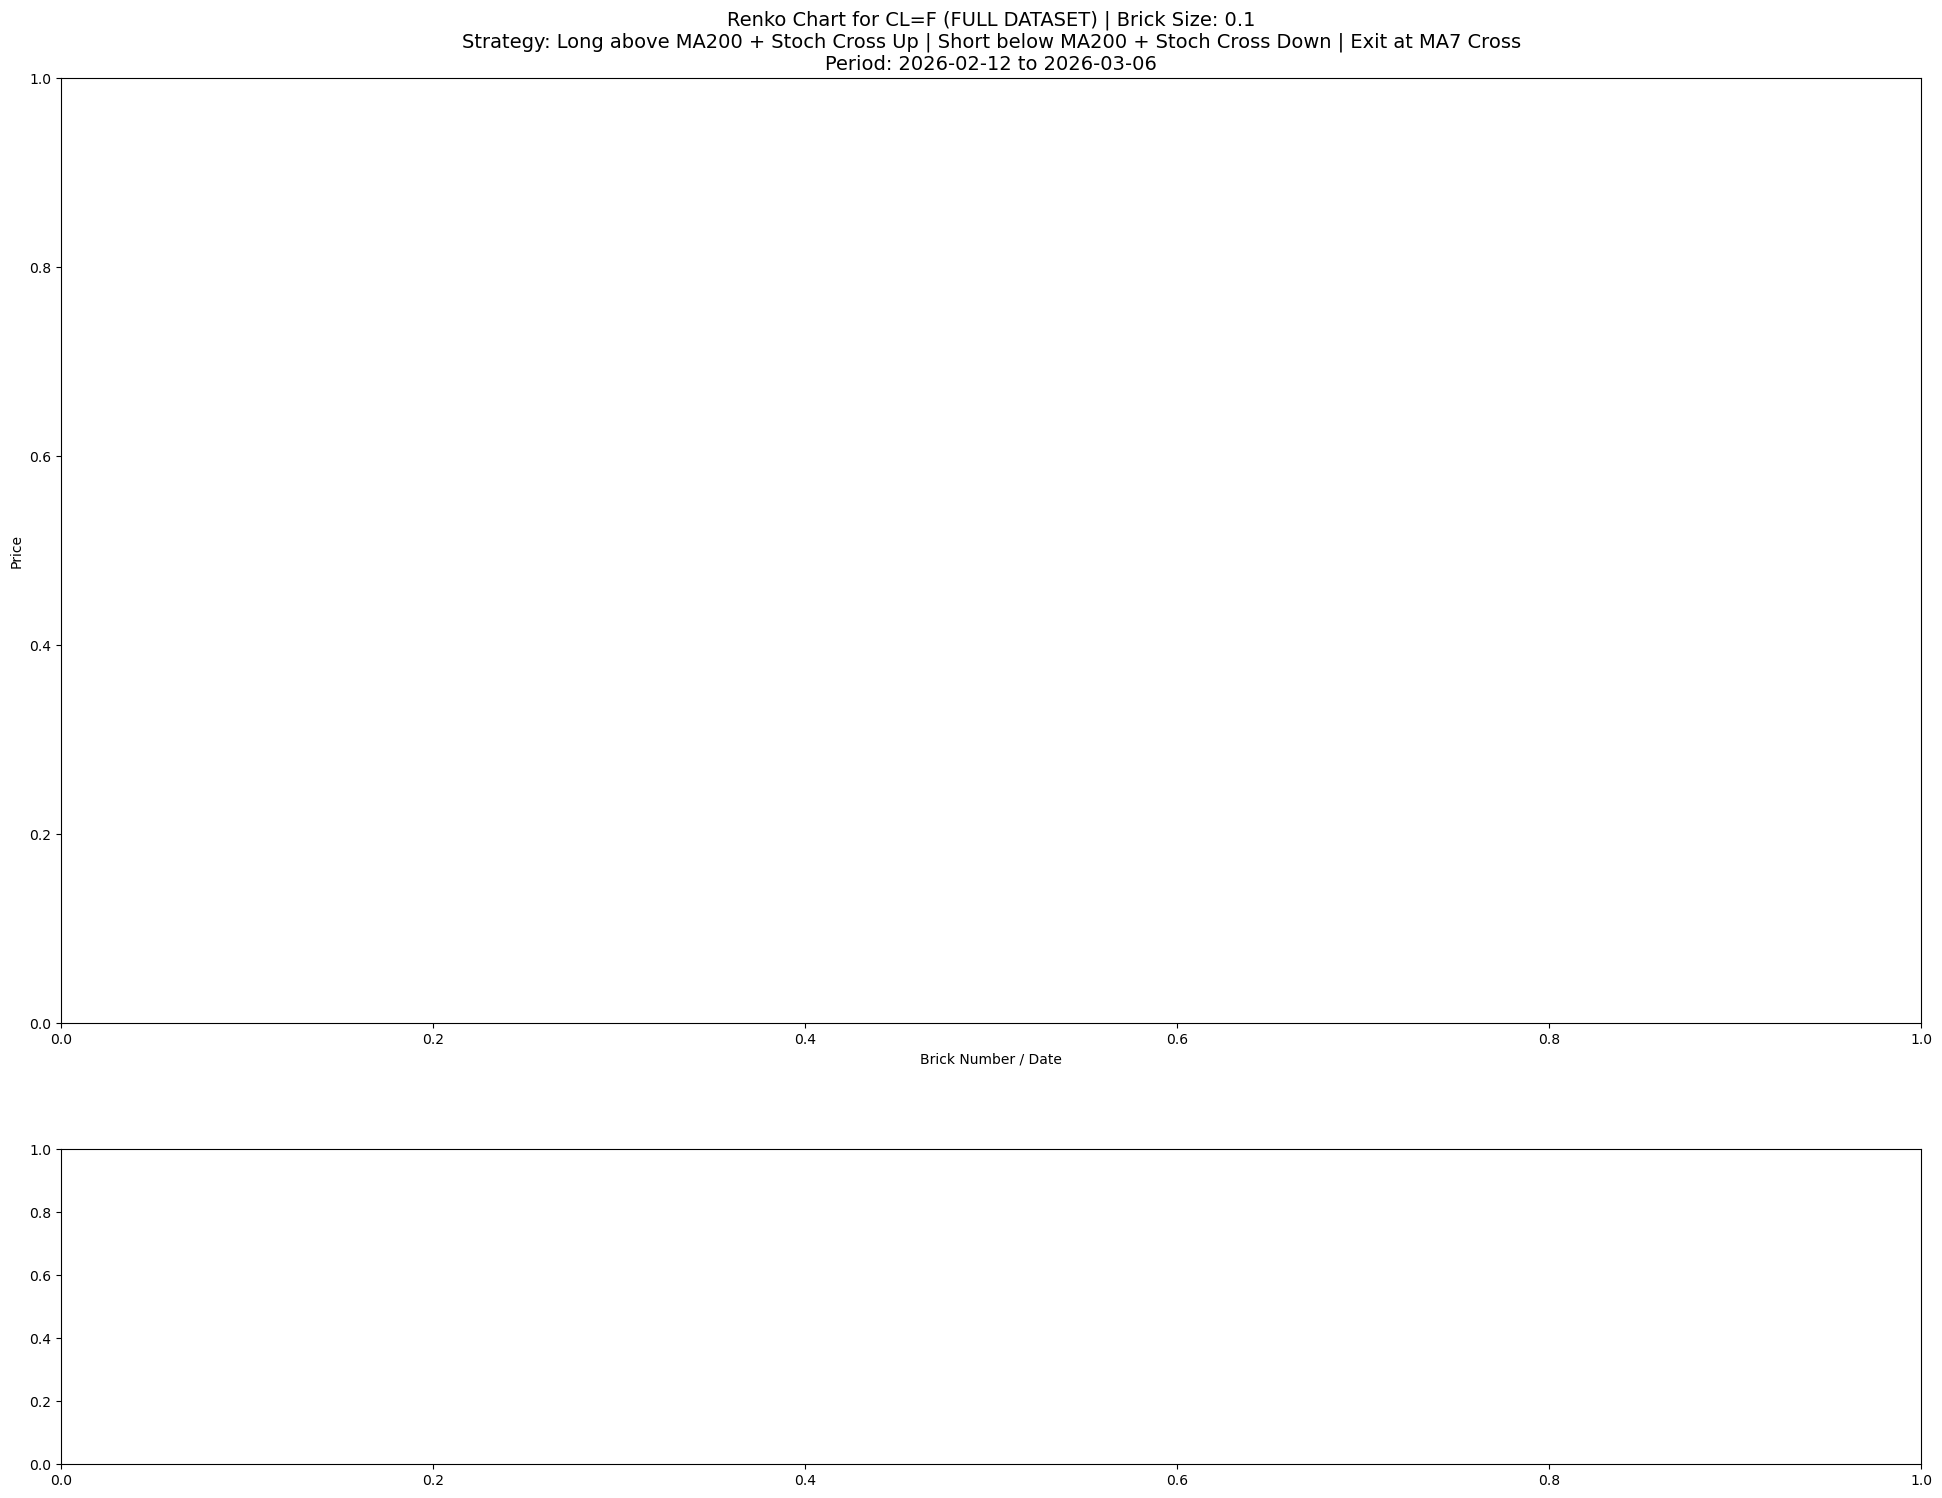

In [13]:
## 9. Plot Renko Chart with Trades (Full Dataset)

# Setup the plot with two subplots: one for Renko, one for Stochastic
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 18), gridspec_kw={'height_ratios': [3, 1]})

# ------------------------------------
# Subplot 1: Renko Chart with Trades
# ------------------------------------

ax1.set_title(f"Renko Chart for {ticker} (FULL DATASET) | Brick Size: {brick_size}\n"
              f"Strategy: Long above MA200 + Stoch Cross Up | Short below MA200 + Stoch Cross Down | Exit at MA7 Cross\n"
              f"Period: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}",
              fontsize=14)
ax1.set_xlabel('Brick Number / Date')
ax1.set_ylabel('Price')

# Plot each brick
for i in range(len(x_positions)):
    color = 'green' if directions[i] == 1 else 'red'
    rect = Rectangle(
        (x_positions[i], y_positions[i]), 1, brick_size,
        facecolor=color, edgecolor='black'
    )
    ax1.add_patch(rect)

# Plot Moving Averages
ax1.plot(x_positions, renko_df['MA7'].tolist(), color='orange', linewidth=2, label='MA 7')
ax1.plot(x_positions, renko_df['MA200'].tolist(), color='blue', linewidth=2, label='MA 200')

# Plot Long Entry Points
long_entries = [t for t in trade_log if t['Type'] == 'LONG']
long_entry_bricks = [t['Entry_Brick'] for t in long_entries]
long_entry_prices = [t['Entry_Price'] for t in long_entries]

if long_entry_bricks:
    ax1.scatter(long_entry_bricks, long_entry_prices, marker='^', color='lime', s=200,
                edgecolors='black', linewidths=1.5, label='Long Entry', zorder=5)

# Plot Short Entry Points
short_entries = [t for t in trade_log if t['Type'] == 'SHORT']
short_entry_bricks = [t['Entry_Brick'] for t in short_entries]
short_entry_prices = [t['Entry_Price'] for t in short_entries]

if short_entry_bricks:
    ax1.scatter(short_entry_bricks, short_entry_prices, marker='v', color='magenta', s=200,
                edgecolors='black', linewidths=1.5, label='Short Entry', zorder=5)

# Plot Exit Points
exit_bricks = [t['Exit_Brick'] for t in trade_log if 'Exit_Brick' in t]
exit_prices = [t['Exit_Price'] for t in trade_log if 'Exit_Price' in t]

if exit_bricks:
    ax1.scatter(exit_bricks, exit_prices, marker='x', color='yellow', s=200,
                linewidths=3, label='Exit', zorder=5)

# Draw lines connecting entry to exit
for trade in trade_log:
    if 'Exit_Brick' in trade:
        pnl = trade.get('PnL', 0)
        line_color = 'cyan' if pnl > 0 else 'orange'
        ax1.plot([trade['Entry_Brick'], trade['Exit_Brick']],
                 [trade['Entry_Price'], trade['Exit_Price']],
                 color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# Add date annotations for trades
for trade in trade_log:
    entry_date = trade.get('Entry_Date')
    if entry_date:
        ax1.annotate(entry_date.strftime('%m/%d'),
                     (trade['Entry_Brick'], trade['Entry_Price']),
                     textcoords="offset points", xytext=(0, 15),
                     fontsize=7, ha='center', color='black',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Set axis limits
ax1.set_xlim(-1, max(x_positions) + 2)
ax1.set_ylim(min(y_positions) - brick_size * 3, max(y_positions) + brick_size * 4)

# Create custom x-axis with dates
# Show date labels at regular intervals
num_ticks = 15
tick_indices = np.linspace(0, len(x_positions) - 1, num_ticks, dtype=int)
tick_labels = [f"{x_positions[i]}\n{renko_df.loc[i, 'Date'].strftime('%m/%d/%y')}" for i in tick_indices]
ax1.set_xticks([x_positions[i] for i in tick_indices])
ax1.set_xticklabels(tick_labels, fontsize=8)

# Y-axis ticks
min_price = min(y_positions)
max_price = max(y_positions)
y_tick_step = max(1, int((max_price - min_price) / brick_size / 20))
ax1.set_yticks([min_price + i * brick_size * y_tick_step
                for i in range(int((max_price - min_price) / (brick_size * y_tick_step)) + 3)])

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize=10)

# -------------------
# Subplot 2: Stochastic Oscillator
# -------------------

ax2.set_title("Stochastic Oscillator (10, 3, 3) - Full Dataset", fontsize=14)
ax2.set_xlabel('Brick Number / Date')
ax2.set_ylabel('%K / %D')

ax2.plot(x_positions, renko_df['%K'].tolist(), label='%K', color='orange', linewidth=2)
ax2.plot(x_positions, renko_df['%D'].tolist(), label='%D', color='purple', linewidth=2)

ax2.axhline(80, color='red', linestyle='--', linewidth=1, label='Overbought (80)')
ax2.axhline(20, color='green', linestyle='--', linewidth=1, label='Oversold (20)')

# Mark entry/exit points on stochastic
if long_entry_bricks:
    ax2.scatter(long_entry_bricks, [renko_df.loc[i, '%K'] for i in long_entry_bricks],
                marker='^', color='lime', s=100, edgecolors='black', zorder=5)

if short_entry_bricks:
    ax2.scatter(short_entry_bricks, [renko_df.loc[i, '%K'] for i in short_entry_bricks],
                marker='v', color='magenta', s=100, edgecolors='black', zorder=5)

if exit_bricks:
    ax2.scatter(exit_bricks, [renko_df.loc[i, '%K'] for i in exit_bricks],
                marker='x', color='yellow', s=100, linewidths=2, zorder=5)

ax2.set_xlim(-1, max(x_positions) + 2)
ax2.set_ylim(-10, 110)
ax2.set_xticks([x_positions[i] for i in tick_indices])
ax2.set_xticklabels(tick_labels, fontsize=8)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## 10. Plot Equity Curve (Full Dataset)
# Create equity curve dataframe with dates
equity_dates = renko_df['Date'].iloc[1:len(equity_curve)+1].reset_index(drop=True)
if len(equity_dates) < len(equity_curve):
    equity_dates = pd.concat([equity_dates, pd.Series([renko_df['Date'].iloc[-1]] * (len(equity_curve) - len(equity_dates)))]).reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(equity_dates, equity_curve, label='Equity Curve', color='blue', linewidth=2)
plt.axhline(y=initial_capital, color='gray', linestyle='--', label='Initial Capital')
plt.title('Strategy Equity Curve (Full Dataset) - Long & Short Trades', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Capital ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 11. Plot Drawdown (Full Dataset)
# Use the same equity_dates from previous cell
drawdown_dates = equity_dates[:len(drawdown)]

plt.figure(figsize=(16, 4))
plt.fill_between(drawdown_dates, drawdown[:len(drawdown_dates)] * 100, color='red', alpha=0.7)
plt.title('Drawdown Over Time (Full Dataset)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
## 12. Trade Log Summary (Full Dataset)
# Display trade log as DataFrame
if trade_log:
    trade_log_df = pd.DataFrame(trade_log)
    
    # Format dates
    if 'Entry_Date' in trade_log_df.columns:
        trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date']).dt.strftime('%Y-%m-%d')
    if 'Exit_Date' in trade_log_df.columns:
        trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date']).dt.strftime('%Y-%m-%d')
    
    # Add profit/loss indicator
    trade_log_df['Result'] = trade_log_df['PnL'].apply(
        lambda x: '✅ WIN' if x > 0 else ('❌ LOSS' if x < 0 else '➖ BE') if pd.notna(x) else '⏳ OPEN'
    )
    
    # Format R:R ratio
    if 'RR_Ratio' in trade_log_df.columns:
        trade_log_df['R:R'] = trade_log_df['RR_Ratio'].apply(lambda x: f"{x:.2f}R" if pd.notna(x) else "N/A")
    
    # Reorder columns
    cols = ['Type', 'Entry_Date', 'Entry_Brick', 'Entry_Price', 'Exit_Date', 'Exit_Brick', 
            'Exit_Price', 'Size', 'PnL', 'R:R', 'Capital', 'Result']
    cols = [c for c in cols if c in trade_log_df.columns]
    trade_log_df = trade_log_df[cols]
    
    display(trade_log_df)
    
    # Summary by trade type
    print("\n" + "=" * 60)
    print("              TRADE SUMMARY BY TYPE")
    print("=" * 60)
    
    for trade_type in ['LONG', 'SHORT']:
        type_trades = [t for t in trade_log if t['Type'] == trade_type and 'PnL' in t]
        if type_trades:
            type_pnl = sum(t['PnL'] for t in type_trades)
            type_wins = len([t for t in type_trades if t['PnL'] > 0])
            type_losses = len([t for t in type_trades if t['PnL'] < 0])
            type_win_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) > 0 and 'RR_Ratio' in t]
            type_loss_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) < 0 and 'RR_Ratio' in t]
            
            print(f"\n{trade_type} Trades:")
            print(f"  Total: {len(type_trades)}")
            print(f"  Wins: {type_wins} | Losses: {type_losses}")
            print(f"  Total PnL: ${type_pnl:,.2f}")
            print(f"  Avg Winning R:R: {np.mean(type_win_rr):.2f}R" if type_win_rr else "  Avg Winning R:R: N/A")
            print(f"  Avg Losing R:R: {np.mean(type_loss_rr):.2f}R" if type_loss_rr else "  Avg Losing R:R: N/A")
        else:
            print(f"\n{trade_type} Trades: None")
    
    # Streak Analysis
    print("\n" + "=" * 60)
    print("              STREAK ANALYSIS")
    print("=" * 60)
    print(f"Maximum Winning Streak: {max_win_streak} consecutive trades")
    print(f"Maximum Losing Streak:  {max_loss_streak} consecutive trades")
    
else:
    print("No trades executed.")

In [ ]:
## 13. Monthly/Yearly Performance Breakdown
# Create a DataFrame to analyze trades over time
if trade_log:
    trade_analysis_df = pd.DataFrame(trade_log)
    
    # Calculate cumulative PnL
    trade_analysis_df['Cumulative_PnL'] = trade_analysis_df['PnL'].cumsum()
    
    # Plot cumulative PnL by trade number
    plt.figure(figsize=(14, 6))
    
    colors = ['green' if x > 0 else 'red' for x in trade_analysis_df['PnL']]
    
    plt.bar(range(len(trade_analysis_df)), trade_analysis_df['PnL'], color=colors, alpha=0.7, label='Trade PnL')
    plt.plot(range(len(trade_analysis_df)), trade_analysis_df['Cumulative_PnL'], 
             color='blue', linewidth=2, marker='o', markersize=4, label='Cumulative PnL')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.title('Individual Trade PnL and Cumulative PnL (Full Dataset)', fontsize=16)
    plt.xlabel('Trade Number')
    plt.ylabel('PnL ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Long vs Short performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Long trades PnL distribution
    long_pnls = [t['PnL'] for t in trade_log if t['Type'] == 'LONG' and 'PnL' in t]
    if long_pnls:
        axes[0].hist(long_pnls, bins=20, color='green', alpha=0.7, edgecolor='black')
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[0].set_title(f'Long Trades PnL Distribution\n(n={len(long_pnls)}, Total=${sum(long_pnls):,.2f})')
        axes[0].set_xlabel('PnL ($)')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True, alpha=0.3)
    
    # Short trades PnL distribution
    short_pnls = [t['PnL'] for t in trade_log if t['Type'] == 'SHORT' and 'PnL' in t]
    if short_pnls:
        axes[1].hist(short_pnls, bins=20, color='magenta', alpha=0.7, edgecolor='black')
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1].set_title(f'Short Trades PnL Distribution\n(n={len(short_pnls)}, Total=${sum(short_pnls):,.2f})')
        axes[1].set_xlabel('PnL ($)')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No trades to analyze.")